In [1]:
library(tidyverse)

homes_df <- read_csv("data/oaklandredfin_v2.csv", name_repair='universal')


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
New names:
• `SALE TYPE` -> `SALE.TYPE`
• `SOLD DATE` -> `SOLD.DATE`
• `PROPERTY TYPE` -> `PROPERTY.TYPE`
• `STATE OR PROVINCE` -> `STATE.OR.PROVINCE`
• `ZIP OR POSTAL CODE` -> `ZIP.OR.POSTAL.CODE`
• `SQUARE FEET` -> `SQUARE.FEET`
• `LOT SIZE` -> `LOT.SIZE`
• `YEAR BUILT` -> `YEAR.BUILT`
• `DAYS ON MARKET` -> `DAYS.ON.MARKET`
• `$/SQUARE FEET` -> `..SQUARE.FEET`
• `HOA/MONTH` -> `HOA.MONTH`
• `NEXT OPEN HOUSE START TIME` -> `NEXT.OPEN.HOUSE.START.TIME`
• `NEXT OPEN HOUSE 

In [2]:
# Count the number of rows
num_rows <- nrow(homes_df)

# Print the result
print(paste("Number of rows before removing non-oakland homes:", num_rows))

# Filter for Oakland homes and calculate price per square foot
oakland_homes <- homes_df %>%
  filter(CITY == "Oakland") %>%
  mutate(price_per_sqft = PRICE / SQUARE.FEET)

# Count the number of rows
num_rows <- nrow(oakland_homes)

# Print the result
print(paste("Number of rows after filtering out non-oakland homes:", num_rows))

# Calculate the average price per square foot in Oakland
avg_price_per_sqft <- oakland_homes %>%
  summarise(avg_price_per_sqft = mean(price_per_sqft, na.rm = TRUE))

avg_price_per_sqft



[1] "Number of rows before removing non-oakland homes: 2237"
[1] "Number of rows after filtering out non-oakland homes: 1956"


avg_price_per_sqft
<dbl>
637.4231


**QUESTION 1:** For each house, calculate the price per square foot. Report the average price per square foot in your selected city?

<span style="font-size:150%;color:green"> 
The average price per squarefoot in Oakland, California is $637.42
</span>

New names:
• `SALE TYPE` -> `SALE.TYPE`
• `SOLD DATE` -> `SOLD.DATE`
• `PROPERTY TYPE` -> `PROPERTY.TYPE`
• `STATE OR PROVINCE` -> `STATE.OR.PROVINCE`
• `ZIP OR POSTAL CODE` -> `ZIP.OR.POSTAL.CODE`
• `SQUARE FEET` -> `SQUARE.FEET`
• `LOT SIZE` -> `LOT.SIZE`
• `YEAR BUILT` -> `YEAR.BUILT`
• `DAYS ON MARKET` -> `DAYS.ON.MARKET`
• `$/SQUARE FEET` -> `..SQUARE.FEET`
• `HOA/MONTH` -> `HOA.MONTH`
• `NEXT OPEN HOUSE START TIME` -> `NEXT.OPEN.HOUSE.START.TIME`
• `NEXT OPEN HOUSE END TIME` -> `NEXT.OPEN.HOUSE.END.TIME`
• `URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR
  INFO ON PRICING)` ->
  `URL..SEE.https...www.redfin.com.buy.a.home.comparative.market.analysis.FOR.INFO.ON.PRICING.`
• `MLS#` -> `MLS.`
Rows: 2237 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): SALE.TYPE, SOLD.DATE, PROPERTY.TYPE, ADDRESS, CITY, STATE.OR.PROVI...
dbl (11): ZIP.OR.POSTAL.CODE, PRICE, BEDS, BATHS, SQUARE.FEET, LOT.SI


Call:
lm(formula = PRICE ~ SQUARE.FEET, data = oakland_homes)

Residuals:
     Min       1Q   Median       3Q      Max 
-3801447  -246827   -76955   187079  3800916 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 2.421e+05  2.053e+04   11.79   <2e-16 ***
SQUARE.FEET 4.820e+02  9.718e+00   49.60   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 493900 on 1948 degrees of freedom
Multiple R-squared:  0.5581,	Adjusted R-squared:  0.5578 
F-statistic:  2460 on 1 and 1948 DF,  p-value: < 2.2e-16


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


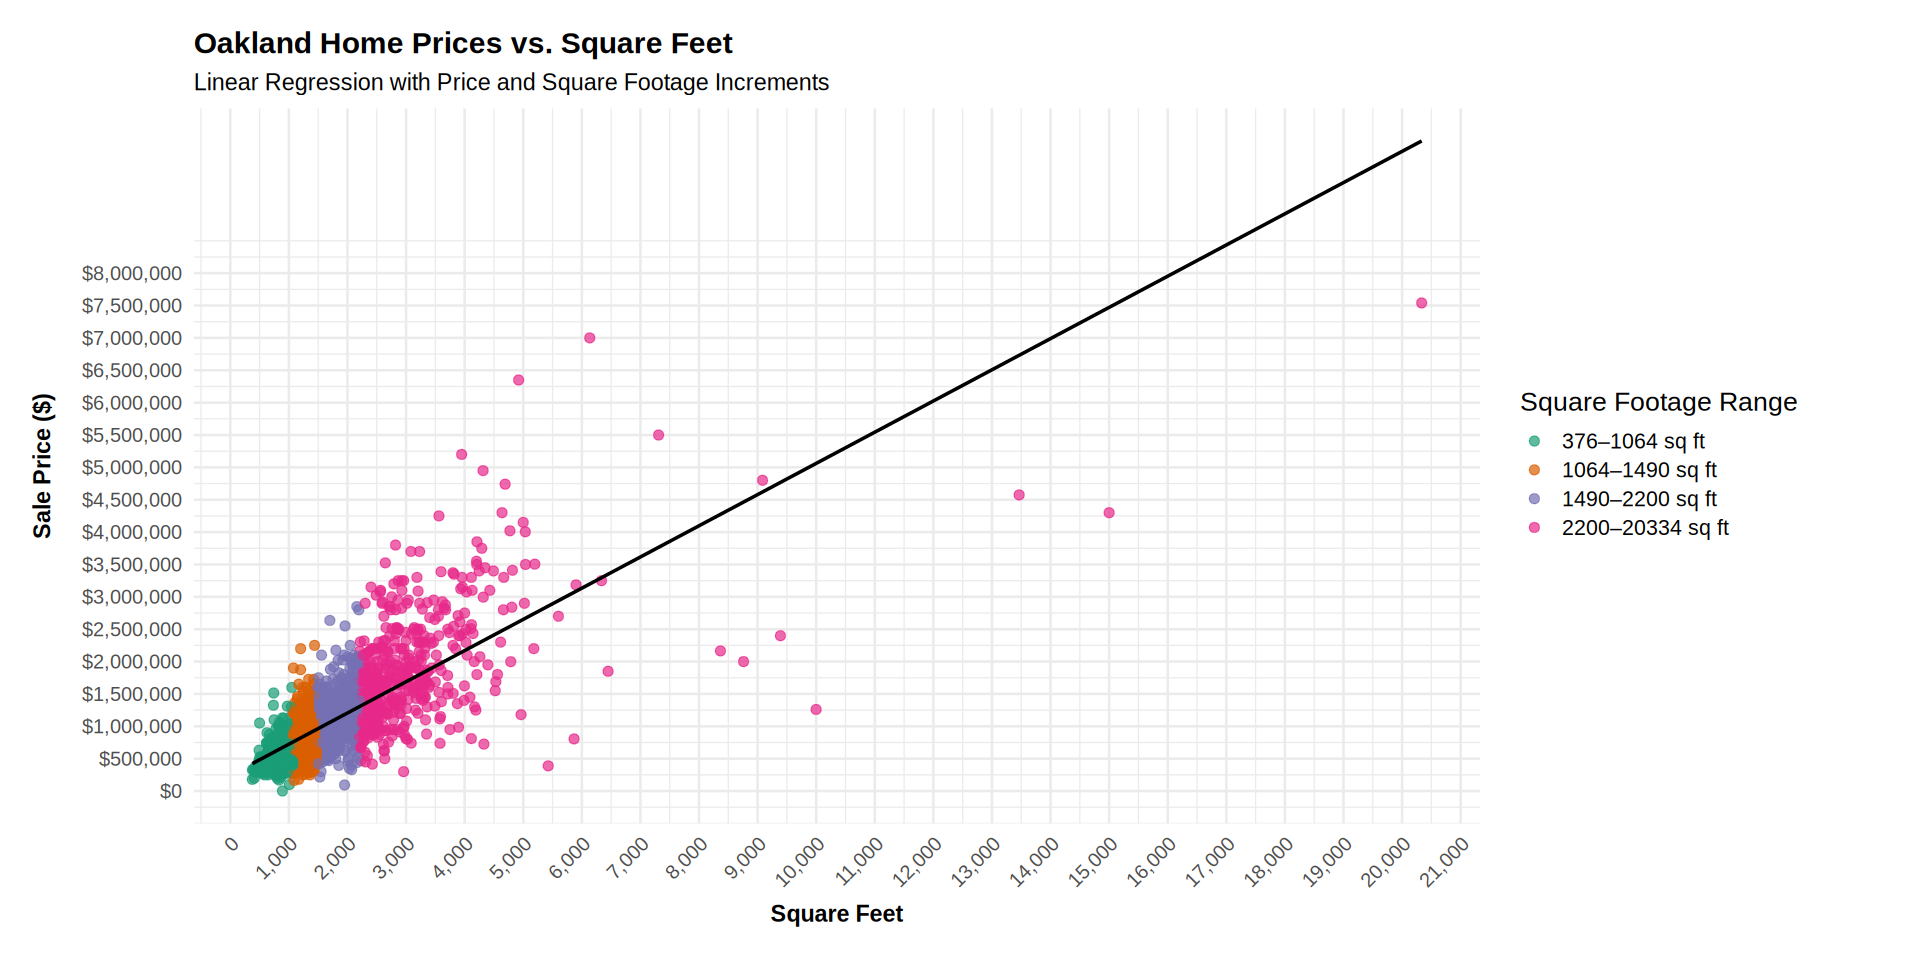

In [24]:
# Load libraries
library(tidyverse)
library(scales)

# Load and clean data
homes_df <- read_csv("data/oaklandredfin_v2.csv", name_repair = 'universal')

oakland_homes <- homes_df %>%
  filter(CITY == "Oakland") %>%
  mutate(
    PRICE = as.numeric(PRICE),
    SQUARE.FEET = as.numeric(SQUARE.FEET)
  ) %>%
  filter(!is.na(PRICE) & PRICE > 0 & !is.na(SQUARE.FEET))

# Run linear regression
model <- lm(PRICE ~ SQUARE.FEET, data = oakland_homes)
summary(model)

# Create square footage range categories (quantile-based)
sqft_breaks <- quantile(oakland_homes$SQUARE.FEET, probs = seq(0, 1, by = 0.25), na.rm = TRUE)

oakland_homes <- oakland_homes %>%
  mutate(
    SQFT_RANGE = cut(
      SQUARE.FEET,
      breaks = sqft_breaks,
      include.lowest = TRUE,
      labels = paste0(
        round(head(sqft_breaks, -1)), "–", round(tail(sqft_breaks, -1)), " sq ft"
      )
    )
  )

# Plot regression with improved readability
plot_oakland <- ggplot(oakland_homes, aes(x = SQUARE.FEET, y = PRICE, color = SQFT_RANGE)) +
  geom_point(alpha = 0.7, size = 2.5) +
  geom_smooth(method = "lm", se = FALSE, color = "black", linewidth = 1) +
  scale_x_continuous(
    breaks = seq(
      floor(min(oakland_homes$SQUARE.FEET, na.rm = TRUE) / 1000) * 1000,
      ceiling(max(oakland_homes$SQUARE.FEET, na.rm = TRUE) / 1000) * 1000,
      by = 1000
    ),
    labels = comma_format()
  ) +
  scale_y_continuous(
    labels = dollar_format(),
    breaks = seq(
      0,
      ceiling(max(oakland_homes$PRICE, na.rm = TRUE) / 500000) * 500000,
      by = 500000
    )
  ) +
  scale_color_manual(
    values = c("#1b9e77", "#d95f02", "#7570b3", "#e7298a"),
    name = "Square Footage Range"
  ) +
  labs(
    title = "Oakland Home Prices vs. Square Feet",
    subtitle = "Linear Regression with Price and Square Footage Increments",
    x = "Square Feet",
    y = "Sale Price ($)"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    legend.position = "right",
    axis.text.x = element_text(size = 12, angle = 45, hjust = 1),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14, face = "bold"),
    plot.title = element_text(size = 18, face = "bold"),
    plot.subtitle = element_text(size = 14),
    plot.margin = margin(20, 40, 20, 20)
  ) +
  coord_cartesian(expand = TRUE)  # expands x-axis area nicely

# Display in a larger interactive window
options(repr.plot.width = 16, repr.plot.height = 8)
plot_oakland

# (Optional) Save high-resolution large version
ggsave("oakland_regression_plot_large.png", plot = plot_oakland, width = 18, height = 9, dpi = 300)


**QUESTION 2:** Run a simple linear regression taking the following form:
𝑆𝐴𝐿𝐸.𝑃𝑅𝐼𝐶𝐸 = β0 + β₁ 𝑆𝑄𝑈𝐴𝑅𝐸.𝐹𝐸𝐸𝑇 + 𝜖 Interpret β₁ and its statistical significance.

<span style="font-size:150%;color:green"> 
The regression results indicate a strong positive relationship between square footage and home price: for each additional square foot, the model predicts an average price increase of approximately $482, and the extremely small p-value (< 2.2e-16) confirms this effect is highly statistically significant. While the intercept of $242,100 represents the predicted price of a home with zero square feet—which is not meaningful in practice—it is required for the model’s calculations.
</span>

New names:
• `SALE TYPE` -> `SALE.TYPE`
• `SOLD DATE` -> `SOLD.DATE`
• `PROPERTY TYPE` -> `PROPERTY.TYPE`
• `STATE OR PROVINCE` -> `STATE.OR.PROVINCE`
• `ZIP OR POSTAL CODE` -> `ZIP.OR.POSTAL.CODE`
• `SQUARE FEET` -> `SQUARE.FEET`
• `LOT SIZE` -> `LOT.SIZE`
• `YEAR BUILT` -> `YEAR.BUILT`
• `DAYS ON MARKET` -> `DAYS.ON.MARKET`
• `$/SQUARE FEET` -> `..SQUARE.FEET`
• `HOA/MONTH` -> `HOA.MONTH`
• `NEXT OPEN HOUSE START TIME` -> `NEXT.OPEN.HOUSE.START.TIME`
• `NEXT OPEN HOUSE END TIME` -> `NEXT.OPEN.HOUSE.END.TIME`
• `URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR
  INFO ON PRICING)` ->
  `URL..SEE.https...www.redfin.com.buy.a.home.comparative.market.analysis.FOR.INFO.ON.PRICING.`
• `MLS#` -> `MLS.`
Rows: 2237 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (13): SALE.TYPE, SOLD.DATE, PROPERTY.TYPE, ADDRESS, CITY, STATE.OR.PROVI...
dbl (11): ZIP.OR.POSTAL.CODE, PRICE, BEDS, BATHS, SQUARE.FEET, LOT.SI


Call:
lm(formula = PRICE ~ SQUARE.FEET + BEDS + BATHS, data = oakland_homes)

Residuals:
     Min       1Q   Median       3Q      Max 
-4604662  -241386   -58958   180105  3393177 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 173059.40   25308.80   6.838 1.07e-11 ***
SQUARE.FEET    570.24      20.41  27.940  < 2e-16 ***
BEDS        -68163.10   12322.81  -5.531 3.61e-08 ***
BATHS        57892.00   17668.91   3.276  0.00107 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 471600 on 1934 degrees of freedom
Multiple R-squared:  0.5779,	Adjusted R-squared:  0.5772 
F-statistic: 882.5 on 3 and 1934 DF,  p-value: < 2.2e-16


Regression equation:
PRICE = 173059.4 + 570.24 * SQUARE.FEET + -68163.1 * BEDS + 57892 * BATHS


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


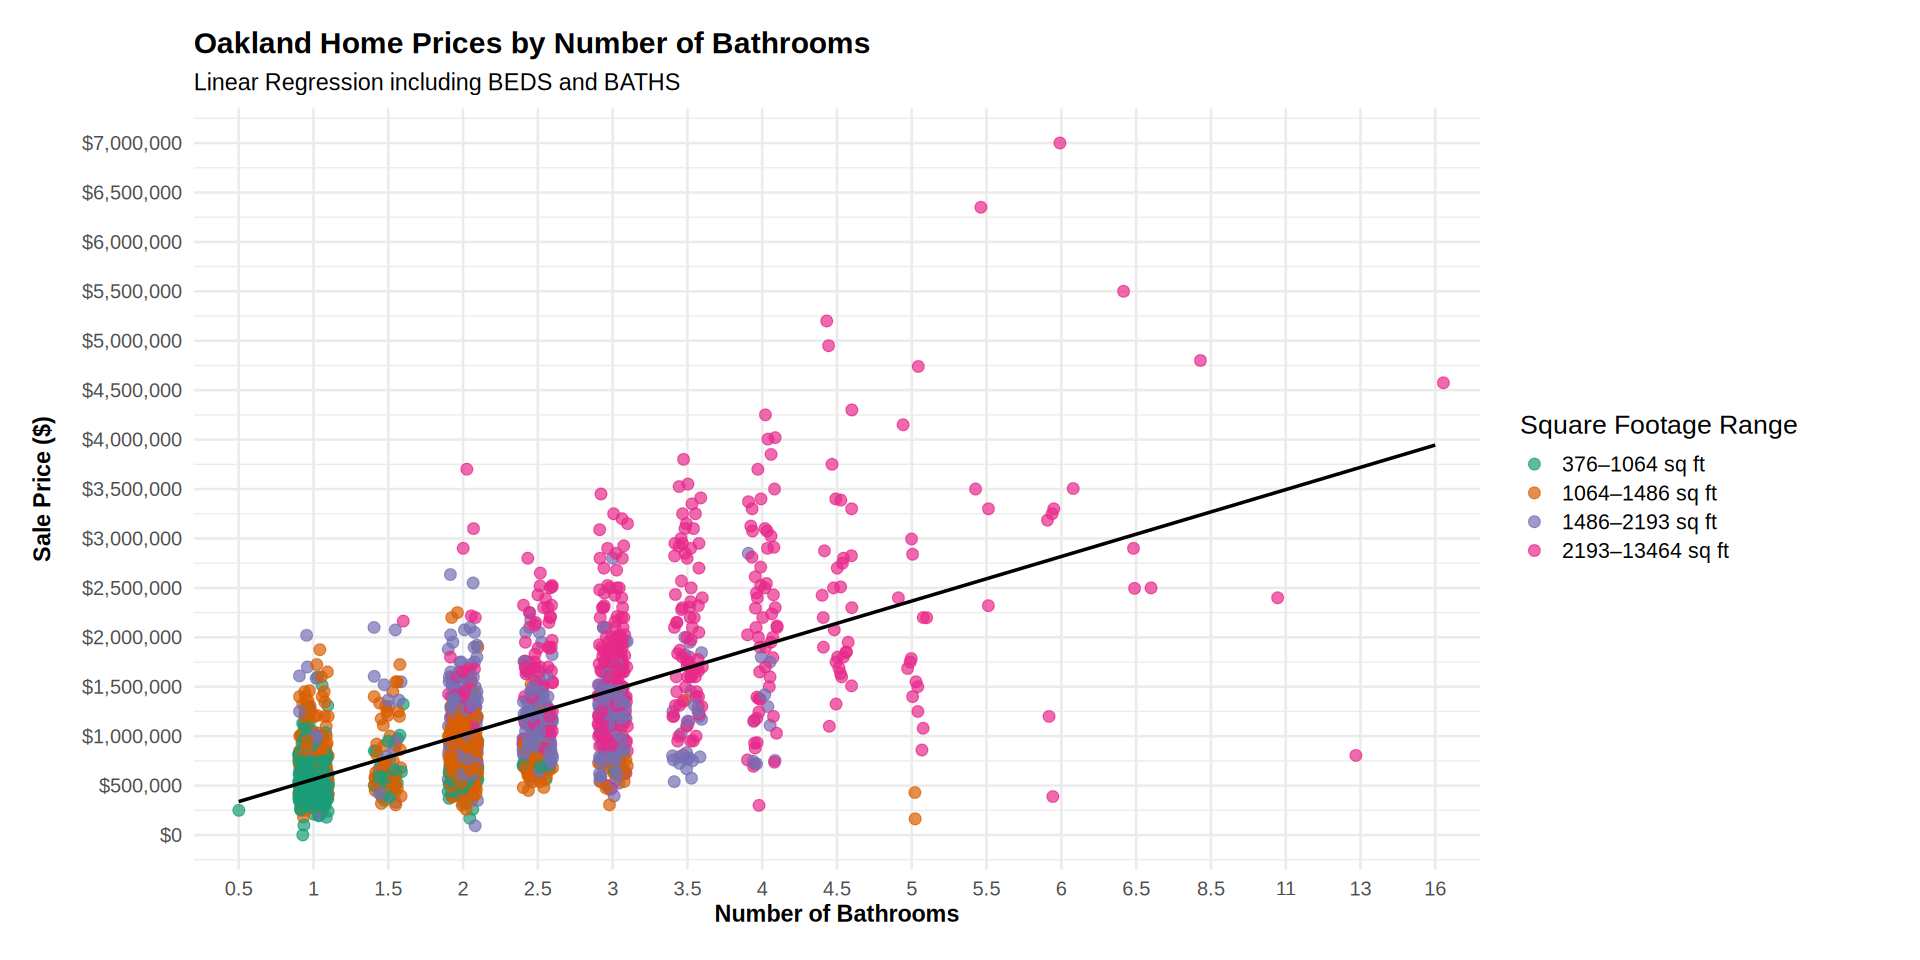

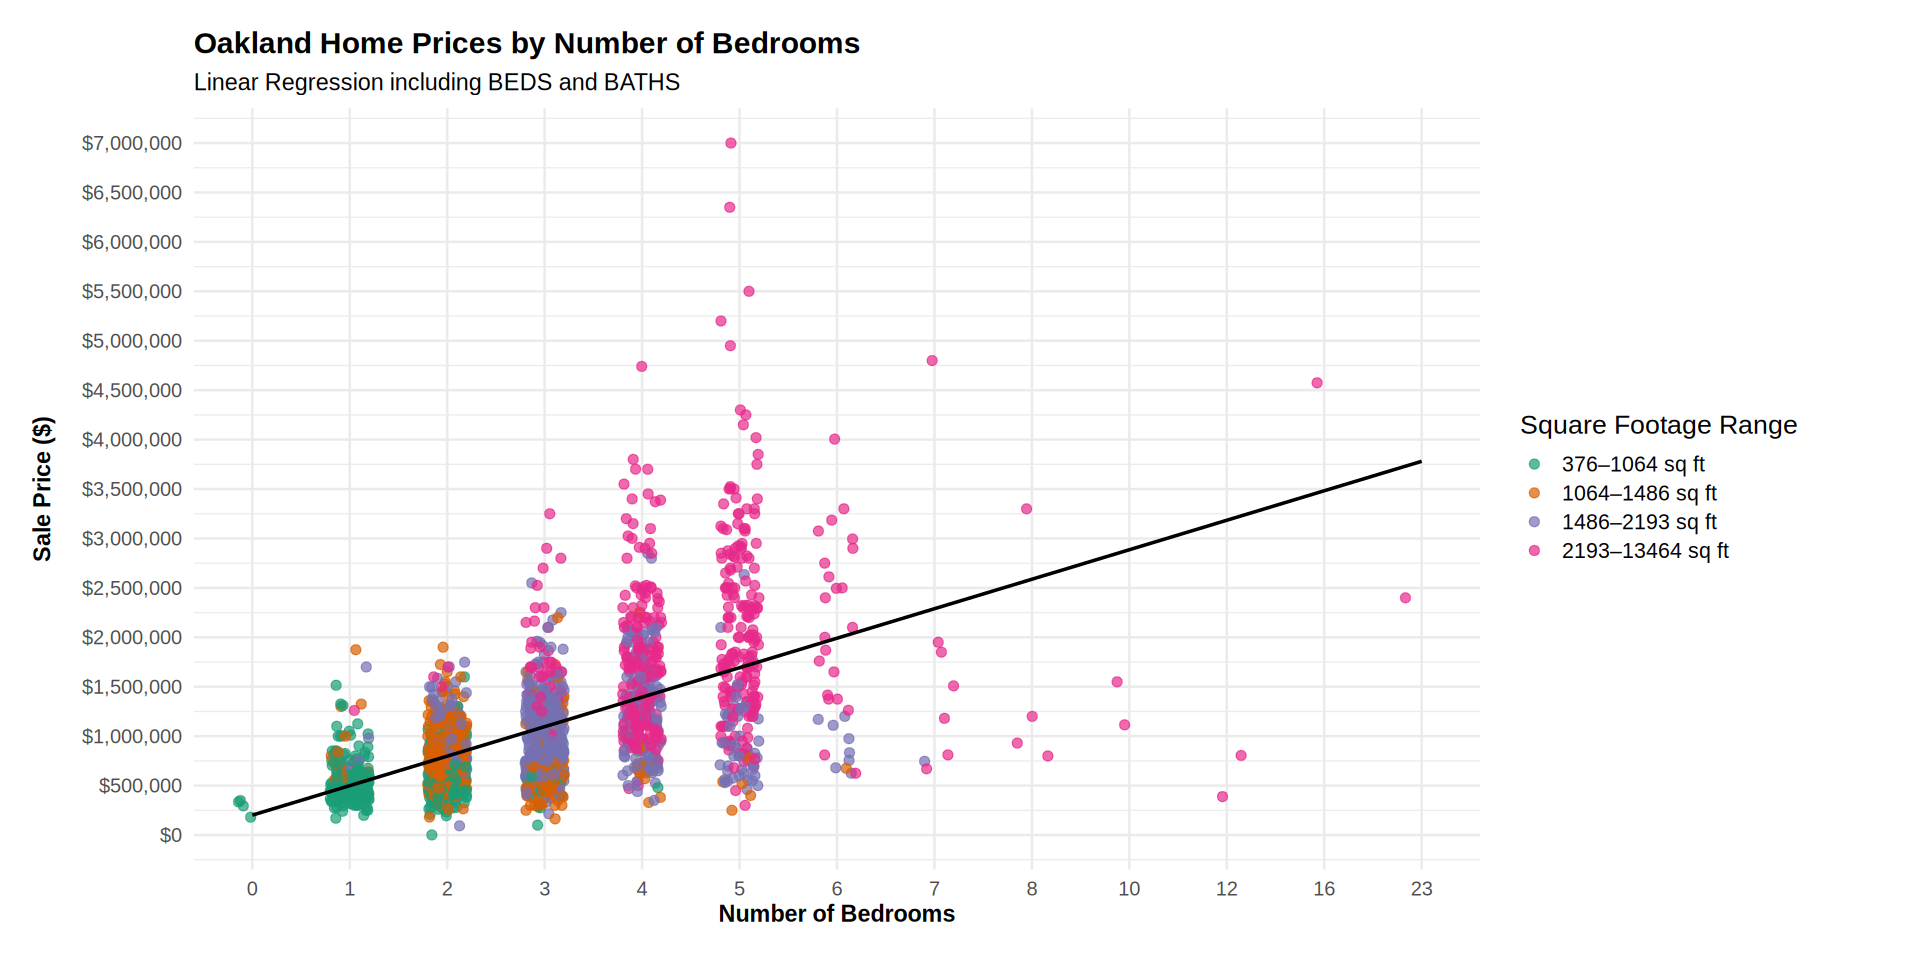

In [5]:
# Load libraries
library(tidyverse)
library(scales)

# Load and clean data
homes_df <- read_csv("data/oaklandredfin_v2.csv", name_repair = 'universal')

oakland_homes <- homes_df %>%
  filter(CITY == "Oakland") %>%
  mutate(
    PRICE = as.numeric(PRICE),
    SQUARE.FEET = as.numeric(SQUARE.FEET),
    BEDS = as.numeric(BEDS),
    BATHS = as.numeric(BATHS)
  ) %>%
  filter(!is.na(PRICE) & PRICE > 0 & !is.na(SQUARE.FEET) & !is.na(BEDS) & !is.na(BATHS))

# Run linear regression with additional explanatory variables BEDS and BATHS
model <- lm(PRICE ~ SQUARE.FEET + BEDS + BATHS, data = oakland_homes)
summary(model)

# Write out the regression equation
cat("Regression equation:\nPRICE =",
    round(coef(model)[1], 2), "+",
    round(coef(model)[2], 2), "* SQUARE.FEET +",
    round(coef(model)[3], 2), "* BEDS +",
    round(coef(model)[4], 2), "* BATHS\n")

# Optional: create square footage ranges for plotting
sqft_breaks <- quantile(oakland_homes$SQUARE.FEET, probs = seq(0, 1, by = 0.25), na.rm = TRUE)
oakland_homes <- oakland_homes %>%
  mutate(
    SQFT_RANGE = cut(
      SQUARE.FEET,
      breaks = sqft_breaks,
      include.lowest = TRUE,
      labels = paste0(
        round(head(sqft_breaks, -1)), "–", round(tail(sqft_breaks, -1)), " sq ft"
      )
    )
  )

# Plot regression with number of bedrooms on x-axis
plot_oakland <- ggplot(oakland_homes, aes(x = factor(BEDS), y = PRICE, color = SQFT_RANGE)) +
  geom_jitter(width = 0.2, alpha = 0.7, size = 2.5) +  # use jitter to avoid overlapping points
  geom_smooth(aes(group = 1), method = "lm", se = FALSE, color = "black", linewidth = 1) +
  scale_y_continuous(
    labels = dollar_format(),
    breaks = seq(
      0,
      ceiling(max(oakland_homes$PRICE, na.rm = TRUE) / 500000) * 500000,
      by = 500000
    )
  ) +
  scale_color_manual(
    values = c("#1b9e77", "#d95f02", "#7570b3", "#e7298a"),
    name = "Square Footage Range"
  ) +
  labs(
    title = "Oakland Home Prices by Number of Bedrooms",
    subtitle = "Linear Regression including BEDS and BATHS",
    x = "Number of Bedrooms",
    y = "Sale Price ($)"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    legend.position = "right",
    axis.text.x = element_text(size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14, face = "bold"),
    plot.title = element_text(size = 18, face = "bold"),
    plot.subtitle = element_text(size = 14),
    plot.margin = margin(20, 40, 20, 20)
  )


# Plot regression with bathrooms on x-axis
plot_oakland_baths <- ggplot(oakland_homes, aes(x = factor(BATHS), y = PRICE, color = SQFT_RANGE)) +
  geom_jitter(width = 0.2, alpha = 0.7, size = 3) +  # jitter to reduce overlap
  geom_smooth(aes(group = 1), method = "lm", se = FALSE, color = "black", linewidth = 1) +
  scale_y_continuous(
    labels = dollar_format(),
    breaks = seq(
      0,
      ceiling(max(oakland_homes$PRICE, na.rm = TRUE) / 500000) * 500000,
      by = 500000
    )
  ) +
  scale_color_manual(
    values = c("#1b9e77", "#d95f02", "#7570b3", "#e7298a"),
    name = "Square Footage Range"
  ) +
  labs(
    title = "Oakland Home Prices by Number of Bathrooms",
    subtitle = "Linear Regression including BEDS and BATHS",
    x = "Number of Bathrooms",
    y = "Sale Price ($)"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    legend.position = "right",
    axis.text.x = element_text(size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14, face = "bold"),
    plot.title = element_text(size = 18, face = "bold"),
    plot.subtitle = element_text(size = 14),
    plot.margin = margin(20, 40, 20, 20)
  )

# Display plot
options(repr.plot.width = 16, repr.plot.height = 8)
plot_oakland_baths

# Display plot in larger interactive window
options(repr.plot.width = 16, repr.plot.height = 8)
plot_oakland





**QUESTION 3:** Run a regression model with the additional explanatory variables of BEDS and BATHS (in addition to SQUARE.FEET). Write out the regression equation. What do you notice about the additional coefficients and how existing coefficients change?

<span style="font-size:150%;color:green"> 
<p>The regression equation after adding BEDS and BATHS is: 
PRICE= B0 + [# of square feet] × SQUARE.FEET + [# of beds] × BEDS + [# of baths] × BATHS.</p>
PRICE= 173,059.40 + 570.24  ×SQUARE.FEET − 68,163.10 × BEDS + 57,892 × BATHS.</p> 
</p>
<span style="font-size:150%;color:green"></span>
<p>BEDS =  </p></span>
<span style="font-size:150%;color:green"> 
<p>BATHS = </p></span>



**QUESTION 4:** If you are analyzing homes other than single family homes. What do you notice when you include the lot size in the regression?

<span style="font-size:150%;color:green"> 
ANSWER: 
</span>


**QUESTION 5:** What fraction of the variation in home prices is explained by your selected variables? How does your model change with the addition of other variables?

<span style="font-size:150%;color:green"> 
ANSWER: 
</span>


**QUESTION 6:** se your model to predict a typical home price. For example, what is the predicted sale price of a 2-bedroom, 2-bath home with 1,500 square feet (or for a typical home in your chosen area)? What is the 95% confidence interval for your prediction?

<span style="font-size:150%;color:green"> 
ANSWER: 
</span>


**QUESTION 7:** How might you use your model to identify investment opportunities in the current housing market in your city?

<span style="font-size:150%;color:green"> 
ANSWER: 
</span>


In [5]:
library(ggplot2)
library(dplyr)
library(readr)
library(leaflet)
library(sf)
library(stringr)
library(lubridate)
library(htmltools)

# --- 1. Load redlining GeoJSON ---
oakland_sf <- st_read("oakland_redlining.geojson", quiet = TRUE)
oakland_sf_valid <- st_make_valid(oakland_sf)
oakland_label_points <- st_point_on_surface(oakland_sf_valid)

# --- 2. Load and filter house data ---
homes_df <- read_csv("data/oaklandredfin_v2.csv", name_repair = 'universal')


# --- 2.5. Load Target store data ---
oakland_targets <- read_csv("data/target.csv", show_col_types = FALSE) %>%
  filter(!is.na(Address.Longitude) & !is.na(Address.Latitude))


oakland_homes <- homes_df %>%
  filter(tolower(CITY) == "oakland") %>%
  mutate(
    PRICE_CATEGORY = case_when(
      PRICE < 500000 ~ "Below $500K",
      PRICE >= 500000 & PRICE < 1000000 ~ "$501K - $999K",
      PRICE >= 1000000 & PRICE < 1500000 ~ "$1M - $1.49M",
      PRICE >= 1500000 ~ "Above $1.5M"
    ),
    COLOR = case_when(
      PRICE_CATEGORY == "Below $500K" ~ "blue",
      PRICE_CATEGORY == "$501K - $999K" ~ "gold",
      PRICE_CATEGORY == "$1M - $1.49M" ~ "purple",
      PRICE_CATEGORY == "Above $1.5M" ~ "red"
    )
  )

# --- 3. Load and clean crime data ---
crime_df <- read_csv("data/CrimeWatch_Maps_Past_90-Days_20251102.csv", show_col_types = FALSE)

crime_df_clean <- crime_df %>%
  filter(!is.na(Location), str_trim(Location) != "") %>%
  mutate(DATETIME = ymd_hms(DATETIME, quiet = TRUE)) %>%
  filter(!is.na(DATETIME)) %>%
  filter(DATETIME >= (as_datetime(Sys.Date()) - days(14)))

crime_sf <- st_as_sf(crime_df_clean, wkt = "Location", crs = 4326, remove = FALSE) %>%
  mutate(
    LON = st_coordinates(.)[, 1],
    LAT = st_coordinates(.)[, 2]
  ) %>%
  filter(!is.na(LON) & !is.na(LAT))

# --- 4. Define HOLC and crime colors ---
holc_colors <- c("A" = "green", "B" = "blue", "C" = "yellow", "D" = "red")

crime_clean <- crime_sf %>%
  mutate(
    CRIME_CATEGORY = case_when(
      str_detect(toupper(CRIMETYPE), "ASSAULT|ROBBERY|HOMICIDE") ~ "Violent Crime",
      str_detect(toupper(CRIMETYPE), "BURGLARY|THEFT|VEHICLE") ~ "Property Crime",
      TRUE ~ "Other"
    ),
    CRIME_COLOR = case_when(
      CRIME_CATEGORY == "Violent Crime" ~ "red",
      CRIME_CATEGORY == "Property Crime" ~ "orange",
      TRUE ~ "gray"
    )
  )

# --- 5. Label text color for HOLC grades ---
oakland_label_points <- oakland_label_points %>%
  mutate(
    label_color = case_when(
      grade %in% c("B", "D") ~ "white",
      TRUE ~ "black"
    )
  )

# ============================
# 1️⃣ Combined Map (with Legends and Black Dots for Target Stores)
# ============================
leaflet() %>%
  addProviderTiles(providers$CartoDB.Positron) %>%
  
  # Redlining Layer
  addPolygons(
    data = oakland_sf_valid,
    group = "Redlining",
    color = "black",
    weight = 1,
    fillColor = ~ifelse(!is.na(grade) & grade %in% names(holc_colors),
                        holc_colors[grade],
                        "gray"),
    fillOpacity = 0.55,
    popup = ~paste0("<b>HOLC Area:</b> ", label, "<br>",
                    "<b>Grade:</b> ", ifelse(is.na(grade), "No Grade", grade))
  ) %>%
  
  # Homes Layer
  addCircleMarkers(
    data = oakland_homes,
    group = "Homes",
    lng = ~LONGITUDE, lat = ~LATITUDE,
    radius = 5, color = "white", weight = 1,
    fillColor = ~COLOR, fillOpacity = 0.9,
    popup = ~paste0("<b>Price:</b> $", formatC(PRICE, format = "f", big.mark = ",", digits = 0),
                    "<br><b>Category:</b> ", PRICE_CATEGORY)
  ) %>%
  
  # Crime Layer (Last 14 Days)
  addCircleMarkers(
    data = crime_clean,
    group = "Crimes",
    lng = ~LON, lat = ~LAT,
    radius = 2.5, color = "white", weight = 1,
    fillColor = ~CRIME_COLOR, fillOpacity = 0.9,
    popup = ~paste0("<b>Crime:</b> ", DESCRIPTION,
                    "<br><b>Type:</b> ", CRIMETYPE,
                    "<br><b>Date:</b> ", DATETIME,
                    "<br><b>Category:</b> ", CRIME_CATEGORY)
  ) %>%
  
  # Target Stores Layer (black dots)
  addCircleMarkers(
    data = oakland_targets,
    group = "Target Stores",
    lng = ~Address.Longitude,
    lat = ~Address.Latitude,
    radius = 7,  # Smaller radius for black dots
    color = "black",  # Black outline
    fillColor = "black",  # Black fill
    fillOpacity = 0.8,
    weight = 2,
    popup = ~paste0(
      "<b>Store Name:</b> ", Name, "<br>",
      "<b>Address:</b> ", Address.FormattedAddress, "<br>",
      "<b>Hours:</b> ", OperatingHours..timeFormat
    )
  ) %>%
  
  # Legends
  addLegend(
    position = "bottomleft",
    colors = c("green", "blue", "yellow", "red", "gray"),
    labels = c("A - BEST", "B - STILL DESIRABLE", "C - DECLINING", "D - HAZARDOUS", "No Grade"),
    title = "HOLC Redlining Grade",
    group = "Redlining"
  ) %>%
  
  addLegend(
    position = "topright",
    colors = c("blue", "gold", "purple", "red"),
    labels = c("Below $500K", "$501K - $999K", "$1M - $1.49M", "Above $1.5M"),
    title = "Home Price Range",
    group = "Homes"
  ) %>%
  
  addLegend(
    position = "bottomleft",
    colors = c("red", "orange", "gray"),
    labels = c("Violent Crime", "Property Crime", "Other"),
    title = "Crime Type (Last 14 Days)",
    group = "Crimes"
  ) %>%
  
  addLegend(
    position = "topleft",
    colors = "black",
    labels = "Target Store",
    title = "Target Locations",
    group = "Target Stores"
  ) %>%
  
  # Layers Control
  addLayersControl(
    overlayGroups = c("Redlining", "Homes", "Crimes", "Target Stores"),
    options = layersControlOptions(collapsed = FALSE),
    position = "topright"
  ) %>%
  
  # Initial Map View and Aspect Ratio
  setView(lng = -122.2711, lat = 37.8044, zoom = 12) %>%
  setMaxBounds(
    lng1 = -122.55, lat1 = 37.6,
    lng2 = -122.15, lat2 = 38.0
  )  # Set boundaries if needed to limit map view


Warning message:
“st_point_on_surface assumes attributes are constant over geometries”
Warning message in st_point_on_surface.sfc(st_geometry(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”
New names:
• `SALE TYPE` -> `SALE.TYPE`
• `SOLD DATE` -> `SOLD.DATE`
• `PROPERTY TYPE` -> `PROPERTY.TYPE`
• `STATE OR PROVINCE` -> `STATE.OR.PROVINCE`
• `ZIP OR POSTAL CODE` -> `ZIP.OR.POSTAL.CODE`
• `SQUARE FEET` -> `SQUARE.FEET`
• `LOT SIZE` -> `LOT.SIZE`
• `YEAR BUILT` -> `YEAR.BUILT`
• `DAYS ON MARKET` -> `DAYS.ON.MARKET`
• `$/SQUARE FEET` -> `..SQUARE.FEET`
• `HOA/MONTH` -> `HOA.MONTH`
• `NEXT OPEN HOUSE START TIME` -> `NEXT.OPEN.HOUSE.START.TIME`
• `NEXT OPEN HOUSE END TIME` -> `NEXT.OPEN.HOUSE.END.TIME`
• `URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR
  INFO ON PRICING)` ->
  `URL..SEE.https...www.redfin.com.buy.a.home.comparative.market.analysis.FOR.INFO.ON.PRICING.`
• `MLS#` -> `MLS.`
Rows: 2237 Columns: 27
── Column specifica

HTML widgets cannot be represented in plain text (need html)

**QUESTION 8:** Based on your knowledge of the city, what other variable(s) would you include to better predict residential home prices? Go ahead and collect the data for (a small sample of) your homes. Interpret your additional results and use them appropriately. You can also consider different models or model specifications. Argued for the importance of your additional analysis for identifying investment opportunities. Be creative!

<span style="font-size:150%;color:green">
ANSWER: 
</span>


In [1]:
install.packages("janitor")
suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(stringr)
  library(tidyr)
  library(purrr)
  library(janitor)
})


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘janitor’ was built under R version 4.5.2”


also installing the dependency ‘snakecase’




In [2]:
library(tidyverse)

homes_df <- read_csv("data/oaklandredfin.csv", name_repair='universal')


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ lubridate 1.9.4
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
New names:
• `SALE TYPE` -> `SALE.TYPE`
• `SOLD DATE` -> `SOLD.DATE`
• `PROPERTY TYPE` -> `PROPERTY.TYPE`
• `STATE OR PROVINCE` -> `STATE.OR.PROVINCE`
• `ZIP OR POSTAL CODE` -> `ZIP.OR.POSTAL.CODE`
• `SQUARE FEET` -> `SQUARE.FEET`
• `LOT SIZE` -> `LOT.SIZE`
• `YEAR BUILT` -> `YEAR.BUILT`
• `DAYS ON MARKET` -> `DAYS.ON.MARKET`
• `$/SQUARE FEET` -> `..SQUARE.FEET`
• `HOA/MONTH` -> `HOA.MONTH`
• `NEXT OPEN HOUSE START TIME` -> `NEXT.OPEN.HOUSE.START.TIME`
• `NEXT OPEN HOUSE END TIME` -> `NEXT.OPEN.HOUSE.END.TIME`
• `URL (SEE https://www.redfin.com/buy-a-home/comparative-marke

# BART proximity calc
Compute distance from each Redfin listing to the nearest BART station, add distance_to_bart_miles and within_0_5_miles_bart.


In [7]:
# BART proximity analysis (R)
# - Clean listings and station data
# - Compute nearest BART distance
# - Add distance_to_bart_miles and within_0_5_miles_bart

suppressPackageStartupMessages({
  library(tidyverse)
  library(sf)
  library(xml2)
  library(purrr)
})

sf::sf_use_s2(TRUE)

# Ensure homes_df exists; otherwise read CSV
if (!exists("homes_df")) {
  homes_df <- readr::read_csv("data/oaklandredfin.csv", show_col_types = FALSE)
}

# Clean: coerce key fields and drop obvious junk (missing coords)
homes_df <- homes_df %>%
  mutate(
    LATITUDE = suppressWarnings(as.numeric(LATITUDE)),
    LONGITUDE = suppressWarnings(as.numeric(LONGITUDE)),
    PRICE = suppressWarnings(as.numeric(PRICE))
  )

homes_with_coords_idx <- which(!is.na(homes_df$LATITUDE) & !is.na(homes_df$LONGITUDE))
if (length(homes_with_coords_idx) == 0) {
  stop("No listings with valid LATITUDE/LONGITUDE found.")
}

homes_sf <- sf::st_as_sf(
  homes_df[homes_with_coords_idx, ],
  coords = c("LONGITUDE", "LATITUDE"), crs = 4326, remove = FALSE
)

# Load BART stations from KMZ (doc.kml inside)
kmz_path <- if (file.exists("data/BART_Stations_2025.kmz")) "data/BART_Stations_2025.kmz" else "402/data/BART_Stations_2025.kmz"
.tmpdir <- tempfile("bart_kmz_")
dir.create(.tmpdir, showWarnings = FALSE)
utils::unzip(kmz_path, files = "doc.kml", exdir = .tmpdir, overwrite = TRUE)

kml <- xml2::read_xml(file.path(.tmpdir, "doc.kml"))

# Extract station names and coordinates using namespace-agnostic XPath
pls <- xml2::xml_find_all(kml, ".//*[local-name()='Placemark']")

get_one <- function(pm) {
  nm <- xml2::xml_text(xml2::xml_find_first(pm, ".//*[local-name()='name']"))
  ct <- xml2::xml_text(xml2::xml_find_first(pm, ".//*[local-name()='Point']/*[local-name()='coordinates']"))
  if (is.na(ct) || is.na(nm) || is.null(ct) || ct == "") return(NULL)
  pts <- strsplit(trimws(ct), ",")[[1]]
  lon <- suppressWarnings(as.numeric(pts[1]))
  lat <- suppressWarnings(as.numeric(pts[2]))
  if (is.na(lon) || is.na(lat)) return(NULL)
  tibble::tibble(station_name = nm, longitude = lon, latitude = lat)
}

stations_df <- purrr::map(pls, get_one) %>%
  dplyr::bind_rows() %>%
  filter(!is.na(longitude), !is.na(latitude)) %>%
  distinct(station_name, longitude, latitude, .keep_all = TRUE)

stations_sf <- sf::st_as_sf(stations_df, coords = c("longitude", "latitude"), crs = 4326, remove = FALSE)

# Compute nearest station distance (miles)
nearest_idx <- sf::st_nearest_feature(homes_sf, stations_sf)
nearest_dist_m <- sf::st_distance(homes_sf, stations_sf[nearest_idx, ], by_element = TRUE)
nearest_dist_miles <- as.numeric(nearest_dist_m) / 1609.344

# Attach back to full homes_df
.dist_full <- rep(NA_real_, nrow(homes_df))
.dist_full[homes_with_coords_idx] <- nearest_dist_miles

homes_df <- homes_df %>%
  mutate(
    distance_to_bart_miles = .dist_full,
    within_0_5_miles_bart = as.integer(!is.na(distance_to_bart_miles) & distance_to_bart_miles <= 0.5)
  )

# Inspection outputs
message("BART stations parsed: ", nrow(stations_sf))
message("Listings with coordinates: ", length(homes_with_coords_idx))

# Show columns inferred from homes_df and a sample of stations
print(head(dplyr::select(homes_df,
  ADDRESS, CITY, LATITUDE, LONGITUDE, PRICE, distance_to_bart_miles, within_0_5_miles_bart
)))
print(head(dplyr::select(stations_df, station_name, latitude, longitude)))


BART stations parsed: 52

Listings with coordinates: 2237



# A tibble: 6 × 7
  ADDRESS               CITY    LATITUDE LONGITUDE  PRICE distance_to_bart_miles
  <chr>                 <chr>      <dbl>     <dbl>  <dbl>                  <dbl>
1 3369 Arkansas St      Oakland     37.8     -122. 6.17e5                  1.60 
2 6846 Saroni Dr        Oakland     37.8     -122. 7.6 e5                  2.90 
3 1004 39th St          Emeryv…     37.8     -122. 2.62e5                  0.553
4 200 Caldecott Ln #106 Oakland     37.9     -122. 3.60e5                  1.89 
5 5101 McDonell Ave     Oakland     37.8     -122. 2.5 e5                  2.64 
6 71 Norman Ln          Oakland     37.8     -122. 1.02e6                  0.997
# ℹ 1 more variable: within_0_5_miles_bart <int>
# A tibble: 6 × 3
  station_name             latitude longitude
  <chr>                       <dbl>     <dbl>
1 Milpitas                     37.4     -122.
2 Berryessa/North San José     37.4     -122.
3 Civic Center/UN Plaza        37.8     -122.
4 Concord                      38.0  

In [8]:
names(homes_df)
summary(homes_df$distance_to_bart_miles)
table(homes_df$within_0_5_miles_bart)


[1] "SALE TYPE"                                                                                  
 [2] "SOLD DATE"                                                                                  
 [3] "PROPERTY TYPE"                                                                              
 [4] "ADDRESS"                                                                                    
 [5] "CITY"                                                                                       
 [6] "STATE OR PROVINCE"                                                                          
 [7] "ZIP OR POSTAL CODE"                                                                         
 [8] "PRICE"                                                                                      
 [9] "BEDS"                                                                                       
[10] "BATHS"                                                                                      
[11] "LOCATION"                                                                                   
[12] "SQUARE FEET"                                                                                
[13] "LOT SIZE"                                                                                   
[14] "YEAR BUILT"                                                                                 
[15] "DAYS ON MARKET"                                                                             
[16] "$/SQUARE FEET"                                                                              
[17] "HOA/MONTH"                                                                                  
[18] "STATUS"                                                                                     
[19] "NEXT OPEN HOUSE START TIME"                                                                 
[20] "NEXT OPEN HOUSE END TIME"                                                                   
[21] "URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR INFO ON PRICING)"
[22] "SOURCE"                                                                                     
[23] "MLS#"                                                                                       
[24] "FAVORITE"                                                                                   
[25] "INTERESTED"                                                                                 
[26] "LATITUDE"                                                                                   
[27] "LONGITUDE"                                                                                  
[28] "distance_to_bart_miles"                                                                     
[29] "within_0_5_miles_bart"

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.09283 0.77284 1.33245 1.49911 2.13287 3.84201 


   0    1 
2008  229 

In [9]:
set.seed(402)  # optional, for reproducible sample
homes_df %>%
  dplyr::sample_n(10) %>%
  dplyr::select(
    ADDRESS, CITY, LATITUDE, LONGITUDE, PRICE,
    distance_to_bart_miles, within_0_5_miles_bart
  )


ADDRESS,CITY,LATITUDE,LONGITUDE,PRICE,distance_to_bart_miles,within_0_5_miles_bart
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
2415 Scenic Ave,Oakland,37.80195,-122.2114,820000,1.9955347,0
5887 Margarido Dr,Oakland,37.84466,-122.2421,2680000,0.5049514,0
38 Windward Hl,Oakland,37.85286,-122.2271,1700000,1.4334272,0
5 Captains Cv,Oakland,37.85610,-122.2260,1700000,1.5891643,0
1669 13th St,Oakland,37.81151,-122.2965,350000,0.4631934,1
103 Alvarado Rd,Berkeley,37.85789,-122.2396,3200000,1.1122170,0
9709 Coral Rd,Oakland,37.73170,-122.1909,275000,1.4524828,0
4392 Terrabella Pl,Oakland,37.79595,-122.1785,1065000,2.8883962,0
6296 Rocky Point Ct,Oakland,37.77862,-122.1623,900000,2.5535283,0


# Quality School proximity calc
Compute distance from each Redfin listing to the nearest quality school station, add distance_to_school_miles and within_2_miles_school.


In [10]:
## School quality proximity (CDE data → homes_df)
install.packages("geosphere")
library(tidyverse)
library(geosphere)


# <-- Add this line (or run it again if you already had it)
data_dir <- "data"


# Helper: pick the first existing column name from a set of candidates
choose_col <- function(df, candidates) {
  found <- candidates[candidates %in% names(df)]
  if (length(found) == 0) {
    stop("None of these columns found: ", paste(candidates, collapse = ", "))
  }
  found[[1]]
}


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘geosphere’


The following object is masked from ‘package:htmltools’:

    span




In [11]:
pubschls_raw <- readr::read_tsv(
  file.path(data_dir, "pubschls.txt"),
  col_types = readr::cols(.default = "c")
)

ela_raw <- readr::read_tsv(
  file.path(data_dir, "eladownload2024.txt"),
  col_types = readr::cols(.default = "c")
)

math_raw <- readr::read_tsv(
  file.path(data_dir, "mathdownload2024.txt"),
  col_types = readr::cols(.default = "c")
)



In [12]:
# Resolve key columns
county_col   <- choose_col(pubschls_raw, c("County", "COUNTY"))
city_col     <- choose_col(pubschls_raw, c("City", "CITY"))
status_col   <- choose_col(pubschls_raw, c("StatusType", "Status", "STATUSTYPE"))
cds_col      <- choose_col(pubschls_raw, c("CDSCode", "CDS", "cds", "CDS_CODE"))
district_col <- choose_col(pubschls_raw, c("District", "DistrictName", "DISTRICT", "DistName"))
school_col   <- choose_col(pubschls_raw, c("School", "SchoolName", "SCHOOL", "SchName"))
street_col   <- choose_col(pubschls_raw, c("Street", "Street1", "Street_Name", "PhysicalStreet"))
zip_col      <- choose_col(pubschls_raw, c("Zip", "ZIP", "ZipCode", "Zipcode", "PhysicalZip"))

# OPTIONAL: try to find a "type" column if it exists
type_candidates <- names(pubschls_raw)[
  stringr::str_detect(names(pubschls_raw), regex("type", ignore_case = TRUE))
]
type_col <- if (length(type_candidates) > 0) type_candidates[[1]] else NA_character_

charter_candidates <- c("Charter", "CharterYN", "CharterFlag", "CharterS")
charter_match <- charter_candidates[charter_candidates %in% names(pubschls_raw)]
charter_col <- if (length(charter_match) > 0) charter_match[[1]] else NA_character_

lat_candidates <- c("Latitude", "LATITUDE", "Lat")
lon_candidates <- c("Longitude", "LONGITUDE", "Lon")

lat_match <- lat_candidates[lat_candidates %in% names(pubschls_raw)]
lon_match <- lon_candidates[lon_candidates %in% names(pubschls_raw)]

lat_col <- if (length(lat_match) > 0) lat_match[[1]] else NA_character_
lon_col <- if (length(lon_match) > 0) lon_match[[1]] else NA_character_

# Base cleaning: filter Alameda / Oakland / Active and standardize fields
pubschls_oakland <- pubschls_raw %>%
  mutate(
    county     = str_trim(.data[[county_col]]),
    city_raw   = str_trim(.data[[city_col]]),
    status_raw = str_trim(.data[[status_col]])
  ) %>%
  filter(
    str_to_upper(county) == "ALAMEDA",
    str_to_upper(city_raw) == "OAKLAND",
    str_to_upper(status_raw) == "ACTIVE"
  ) %>%
  mutate(
    cds_code      = str_pad(str_trim(.data[[cds_col]]), width = 14, side = "left", pad = "0"),
    district_name = .data[[district_col]] %>% str_squish() %>% str_to_title(),
    school_name   = .data[[school_col]]   %>% str_squish() %>% str_to_title(),
    street        = .data[[street_col]]   %>% str_squish() %>% str_to_title(),
    city          = city_raw %>% str_squish() %>% str_to_title(),
    zip_code      = .data[[zip_col]] %>% str_extract("\\d{5}"),
    school_type   = if (!is.na(type_col)) .data[[type_col]] else NA_character_
  )

# Charter flag: handle presence/absence of charter column safely
if (!is.na(charter_col)) {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(
      charter_flag = case_when(
        str_to_upper(str_trim(.data[[charter_col]])) %in% c("Y", "YES", "CHARTER") ~ 1L,
        str_trim(.data[[charter_col]]) == "" ~ NA_integer_,
        TRUE ~ 0L
      )
    )
} else {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(charter_flag = NA_integer_)
}

# Latitude / longitude (if present)
if (!is.na(lat_col)) {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(latitude = suppressWarnings(as.numeric(.data[[lat_col]])))
} else {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(latitude = NA_real_)
}

if (!is.na(lon_col)) {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(longitude = suppressWarnings(as.numeric(.data[[lon_col]])))
} else {
  pubschls_oakland <- pubschls_oakland %>%
    mutate(longitude = NA_real_)
}

# Final column selection and de-dup
pubschls_oakland <- pubschls_oakland %>%
  select(
    cds_code,
    district_name,
    school_name,
    street,
    city,
    zip_code,
    school_type,
    charter_flag,
    latitude,
    longitude
  ) %>%
  distinct(cds_code, .keep_all = TRUE)

pubschls_oakland %>% head()

cds_code,district_name,school_name,street,city,zip_code,school_type,charter_flag,latitude,longitude
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
01100170112607,Alameda County Office Of Education,Envision Academy For Arts & Technology,1515 Webster Street,Oakland,94612,Active,1,37.80452,-122.2682
01100170114363,Alameda County Office Of Education,American Indian Public Charter School Ii,171 12th Street,Oakland,94607,Active,1,37.80037,-122.2655
01100170123968,Alameda County Office Of Education,Community School For Creative Education,2111 International Boulevard,Oakland,94606,Active,1,37.78465,-122.2386
01100170124172,Alameda County Office Of Education,Yu Ming Charter,2501 Chestnut Street,Oakland,94607,Active,1,37.81823,-122.2823
01100170126748,Alameda County Office Of Education,Lps Oakland R & D Campus,"8601 Macarthur Boulevard, Building 100",Oakland,94605,Active,1,37.75954,-122.1629
01100170129403,Alameda County Office Of Education,Epic Charter,1045 Derby Avenue,Oakland,94601,Active,0,37.77705,-122.2296


In [13]:
clean_dashboard_subject <- function(df_raw, subject_prefix) {
  cds_col         <- choose_col(df_raw, c("CDSCode", "CDS", "cds"))
  rtype_col       <- choose_col(df_raw, c("rtype", "RType"))
  student_col     <- choose_col(df_raw, c("studentgroup", "StudentGroup", "student_group"))
  currstatus_col  <- choose_col(df_raw, c("currstatus", "CurrStatus"))
  statuslevel_col <- choose_col(df_raw, c("statuslevel", "StatusLevel"))
  color_col       <- choose_col(df_raw, c("color", "Color"))
  
  level_to_label <- c(
    `1` = "Very Low / Red",
    `2` = "Low / Orange",
    `3` = "Medium / Yellow",
    `4` = "High / Green",
    `5` = "Very High / Blue"
  )
  
  df_raw %>%
    mutate(
      rtype        = str_to_upper(str_trim(.data[[rtype_col]])),
      studentgroup = str_to_upper(str_trim(.data[[student_col]]))
    ) %>%
    filter(
      rtype == "S",
      studentgroup == "ALL"
    ) %>%
    mutate(
      cds_code = str_pad(str_trim(.data[[cds_col]]), width = 14, side = "left", pad = "0"),
      !!paste0(subject_prefix, "_distance") := suppressWarnings(as.numeric(.data[[currstatus_col]])),
      !!paste0(subject_prefix, "_statuslevel") := suppressWarnings(as.numeric(.data[[statuslevel_col]])),
      !!paste0(subject_prefix, "_color_code") := str_trim(.data[[color_col]]),
      !!paste0(subject_prefix, "_status_label") :=
        recode(as.character(.data[[statuslevel_col]]), !!!level_to_label)
    ) %>%
    select(
      cds_code,
      starts_with(paste0(subject_prefix, "_"))
    ) %>%
    distinct(cds_code, .keep_all = TRUE)
}

ela_clean  <- clean_dashboard_subject(ela_raw,  "ela")
math_clean <- clean_dashboard_subject(math_raw, "math")

ela_clean %>% head()
math_clean %>% head()

cds_code,ela_distance,ela_statuslevel,ela_color_code,ela_status_label
<chr>,<dbl>,<dbl>,<chr>,<chr>
01100170112607,-84.8,1,1,Very Low / Red
01100170123968,-82.8,1,1,Very Low / Red
01100170124172,83.8,5,4,Very High / Blue
01100170125567,-34.3,2,2,Low / Orange
01100170130401,NA,0,0,0
01100170130419,-218.3,1,0,Very Low / Red


cds_code,math_distance,math_statuslevel,math_color_code,math_status_label
<chr>,<dbl>,<dbl>,<chr>,<chr>
01100170112607,-165.1,1,1,Very Low / Red
01100170123968,-114.4,1,1,Very Low / Red
01100170124172,99.5,5,4,Very High / Blue
01100170125567,-63.3,2,3,Low / Orange
01100170130401,NA,0,0,0
01100170130419,-259.3,1,0,Very Low / Red


In [14]:
# Merge math + ELA at school level
school_perf <- math_clean %>%
  full_join(ela_clean, by = "cds_code")

# Continuous index: average of math_distance and ela_distance
school_perf <- school_perf %>%
  mutate(
    school_quality_distance = {
      dist_mat <- select(., math_distance, ela_distance) %>%
        mutate(across(everything(), as.numeric)) %>%
        as.matrix()
      
      row_mean <- rowMeans(dist_mat, na.rm = TRUE)
      # if both NA → rowMeans gives NaN, fix that
      both_na <- apply(is.na(dist_mat), 1, all)
      row_mean[both_na] <- NA_real_
      row_mean
    }
  )

# Categorical index: rounded average of math_statuslevel and ela_statuslevel
school_perf <- school_perf %>%
  mutate(
    school_quality_level = {
      lvl_mat <- select(., math_statuslevel, ela_statuslevel) %>%
        mutate(across(everything(), as.numeric)) %>%
        as.matrix()
      
      lvl_mean <- rowMeans(lvl_mat, na.rm = TRUE)
      both_na <- apply(is.na(lvl_mat), 1, all)
      lvl_mean[both_na] <- NA_real_
      as.integer(round(lvl_mean))
    }
  )

# Optional label for school_quality_level
level_to_label <- c(
  `1` = "Very Low / Red",
  `2` = "Low / Orange",
  `3` = "Medium / Yellow",
  `4` = "High / Green",
  `5` = "Very High / Blue"
)

school_perf <- school_perf %>%
  mutate(
    school_quality_label = recode(as.character(school_quality_level), !!!level_to_label)
  )

# Join onto Oakland schools
oakland_schools_perf <- pubschls_oakland %>%
  left_join(school_perf, by = "cds_code")

oakland_schools_perf %>% head()


cds_code,district_name,school_name,street,city,zip_code,school_type,charter_flag,latitude,longitude,⋯,math_statuslevel,math_color_code,math_status_label,ela_distance,ela_statuslevel,ela_color_code,ela_status_label,school_quality_distance,school_quality_level,school_quality_label
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<chr>
01100170112607,Alameda County Office Of Education,Envision Academy For Arts & Technology,1515 Webster Street,Oakland,94612,Active,1,37.80452,-122.2682,⋯,1,1,Very Low / Red,-84.8,1,1,Very Low / Red,-124.95,1,Very Low / Red
01100170114363,Alameda County Office Of Education,American Indian Public Charter School Ii,171 12th Street,Oakland,94607,Active,1,37.80037,-122.2655,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
01100170123968,Alameda County Office Of Education,Community School For Creative Education,2111 International Boulevard,Oakland,94606,Active,1,37.78465,-122.2386,⋯,1,1,Very Low / Red,-82.8,1,1,Very Low / Red,-98.60,1,Very Low / Red
01100170124172,Alameda County Office Of Education,Yu Ming Charter,2501 Chestnut Street,Oakland,94607,Active,1,37.81823,-122.2823,⋯,5,4,Very High / Blue,83.8,5,4,Very High / Blue,91.65,5,Very High / Blue
01100170126748,Alameda County Office Of Education,Lps Oakland R & D Campus,"8601 Macarthur Boulevard, Building 100",Oakland,94605,Active,1,37.75954,-122.1629,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
01100170129403,Alameda County Office Of Education,Epic Charter,1045 Derby Avenue,Oakland,94601,Active,0,37.77705,-122.2296,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [15]:
q75 <- oakland_schools_perf %>%
  filter(!is.na(school_quality_distance)) %>%
  pull(school_quality_distance) %>%
  as.numeric() %>%
  quantile(probs = 0.75, na.rm = TRUE)

oakland_schools_perf <- oakland_schools_perf %>%
  mutate(
    is_quality_school =
      !is.na(school_quality_distance) &
      school_quality_distance >= q75 &
      !is.na(school_quality_level) &
      school_quality_level >= 4
  )



In [16]:
library(dplyr)
library(tidyr)

# Haversine helper (only needs to be defined once per kernel)
haversine_miles <- function(lat1, lon1, lat2, lon2) {
  rad <- pi / 180
  lat1 <- lat1 * rad
  lon1 <- lon1 * rad
  lat2 <- lat2 * rad
  lon2 <- lon2 * rad
  
  dlat <- lat2 - lat1
  dlon <- lon2 - lon1
  
  a <- sin(dlat / 2)^2 + cos(lat1) * cos(lat2) * sin(dlon / 2)^2
  c <- 2 * asin(pmin(1, sqrt(a)))
  
  earth_radius_miles <- 3958.8
  earth_radius_miles * c
}

# Home lat/lon columns
lat_home_col <- choose_col(homes_df, c("LATITUDE", "Latitude", "lat", "Lat"))
lon_home_col <- choose_col(homes_df, c("LONGITUDE", "Longitude", "lon", "Lon", "lng"))

# Use only strict "quality" schools with valid coords
schools_for_dist <- oakland_schools_perf %>%
  filter(
    is_quality_school,
    !is.na(latitude),
    !is.na(longitude)
  ) %>%
  transmute(
    cds_code,
    school_name,
    school_lat = as.numeric(latitude),
    school_lon = as.numeric(longitude),
    school_quality_distance,
    school_quality_level
  )

if (nrow(schools_for_dist) == 0) {
  warning("No quality schools with valid latitude/longitude; skipping distance features.")
} else {
  # 1) Add an index to homes
  homes_with_idx <- homes_df %>%
    mutate(home_idx = dplyr::row_number())
  
  # 2) Cross join homes × quality schools and compute distances
  pairs <- homes_with_idx %>%
    transmute(
      home_idx,
      home_lat = as.numeric(.data[[lat_home_col]]),
      home_lon = as.numeric(.data[[lon_home_col]])
    ) %>%
    tidyr::crossing(schools_for_dist) %>%
    mutate(
      distance_to_quality_school_miles = haversine_miles(
        home_lat, home_lon,
        school_lat, school_lon
      )
    )
  
  # 3) Nearest quality school per home
  nearest_quality <- pairs %>%
    group_by(home_idx) %>%
    slice_min(distance_to_quality_school_miles, n = 1, with_ties = FALSE) %>%
    ungroup()
  
  # 4) Join back onto homes_df and create the 2-mile flag
  homes_df <- homes_with_idx %>%
    left_join(
      nearest_quality %>%
        select(
          home_idx,
          distance_to_quality_school_miles,
          nearest_quality_school_name             = school_name,
          nearest_quality_school_quality_distance = school_quality_distance,
          nearest_quality_school_quality_level    = school_quality_level
        ),
      by = "home_idx"
    ) %>%
    mutate(
      within_2_miles_quality_school = if_else(
        !is.na(distance_to_quality_school_miles) &
          distance_to_quality_school_miles <= 2,
        1L, 0L
      )
    ) %>%
    select(-home_idx)
}


In [17]:
names(homes_df)[grepl("quality_school", names(homes_df))]

[1] "distance_to_quality_school_miles"       
[2] "nearest_quality_school_name"            
[3] "nearest_quality_school_quality_distance"
[4] "nearest_quality_school_quality_level"   
[5] "within_2_miles_quality_school"

In [18]:
homes_df <- homes_df %>%
  mutate(
    within_0_5_mile_quality_school = if_else(
      !is.na(distance_to_quality_school_miles) &
        distance_to_quality_school_miles <= 0.5,
      1L, 0L
    )
  )


In [19]:
homes_df %>%
  summarise(
    n_homes                     = n(),
    pct_within_0_5_mile_quality = mean(within_0_5_mile_quality_school == 1, na.rm = TRUE) * 100
  )

set.seed(123)
homes_df %>%
  select(
    ADDRESS = `ADDRESS`,
    `ZIP OR POSTAL CODE`,
    distance_to_quality_school_miles,
    within_0_5_mile_quality_school,
    nearest_quality_school_name
  ) %>%
  slice_sample(n = 10)


n_homes,pct_within_0_5_mile_quality
<int>,<dbl>
2237,27.8945


ADDRESS,ZIP OR POSTAL CODE,distance_to_quality_school_miles,within_0_5_mile_quality_school,nearest_quality_school_name
<chr>,<dbl>,<dbl>,<int>,<chr>
402 Hiller Dr,94618,0.9348404,0,Chabot Elementary
1116 16th St,94607,0.5112752,0,Yu Ming Charter
2033 Harrington Ave,94601,1.3634555,0,Downtown Charter Academy
6258 Boulder Ln #4801,94605,1.2108160,0,Oakland Unity High
1009 Winsor Ave,94610,0.6422999,0,Crocker Highlands Elementary
4614 Rockingham Ct,94619,1.4272076,0,Oakland Unity High
868 44th St,94608,1.2106267,0,Yu Ming Charter
9057 Skyline Blvd,94611,0.8712733,0,Joaquin Miller Elementary
6907 Chambers Dr,94611,0.6811770,0,Thornhill Elementary


In [20]:
library(dplyr)

set.seed(432)  # optional, just for reproducibility

homes_sample <- homes_df %>%
  # grab some core listing fields + all the school-quality stuff
  select(
    ADDRESS                = any_of("ADDRESS"),
    CITY                   = any_of("CITY"),
    `ZIP OR POSTAL CODE`,
    PRICE                  = any_of("PRICE"),
    LATITUDE               = any_of("LATITUDE"),
    LONGITUDE              = any_of("LONGITUDE"),
    distance_to_quality_school_miles,
    within_2_miles_quality_school,
    nearest_quality_school_name,
    nearest_quality_school_quality_distance,
    nearest_quality_school_quality_level,
    # if you added nearest-any-school columns, these will show too:
    nearest_school_distance_miles  = any_of("nearest_school_distance_miles"),
    nearest_school_name            = any_of("nearest_school_name"),
    nearest_school_quality_distance = any_of("nearest_school_quality_distance"),
    nearest_school_quality_level    = any_of("nearest_school_quality_level"),
    nearest_school_is_quality       = any_of("nearest_school_is_quality")
  ) %>%
  slice_sample(n = 5)

homes_sample


ADDRESS,CITY,ZIP OR POSTAL CODE,PRICE,LATITUDE,LONGITUDE,distance_to_quality_school_miles,within_2_miles_quality_school,nearest_quality_school_name,nearest_quality_school_quality_distance,nearest_quality_school_quality_level
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<int>
10127 Dante Ave,Oakland,94603,400000,37.74445,-122.1583,0.4812861,1,Francophone Charter School Of Oakland,10.10,4
622 Carlston Ave,Oakland,94610,2850000,37.81038,-122.2321,0.2667199,1,Crocker Highlands Elementary,48.25,5
630 Thomas L Berkley Way #713,Oakland,94612,615000,37.81022,-122.2724,0.7545721,1,Lincoln Elementary,27.60,4
2226 19th Ave,Oakland,94606,582500,37.79261,-122.2348,0.8282855,1,Edna Brewer Middle,-3.85,4
2830 Ritchie St,Oakland,94605,450000,37.76483,-122.1658,1.0411490,1,Francophone Charter School Of Oakland,10.10,4


In [21]:
oakland_schools_perf %>%
  count(is_quality_school)


is_quality_school,n
<lgl>,<int>
FALSE,110
TRUE,17


In [22]:
oakland_schools_perf %>%
  summarise(
    n_schools                = sum(!is.na(school_quality_distance)),
    q25                      = quantile(school_quality_distance, 0.25, na.rm = TRUE),
    q50                      = quantile(school_quality_distance, 0.50, na.rm = TRUE),
    q75                      = quantile(school_quality_distance, 0.75, na.rm = TRUE),
    max_quality_distance     = max(school_quality_distance, na.rm = TRUE)
  )


n_schools,q25,q50,q75,max_quality_distance
<int>,<dbl>,<dbl>,<dbl>,<dbl>
108,-113.875,-83.05,-39.05,91.65


In [23]:
homes_df %>%
  summarise(
    n_homes                 = n(),
    pct_within_2_miles      = mean(within_2_miles_quality_school == 1, na.rm = TRUE) * 100,
    pct_within_1_5_miles    = mean(distance_to_quality_school_miles <= 1.5, na.rm = TRUE) * 100,
    pct_within_1_mile       = mean(distance_to_quality_school_miles <= 1, na.rm = TRUE) * 100,
    pct_within_0_5_mile     = mean(distance_to_quality_school_miles <= 0.5, na.rm = TRUE) * 100
  )


n_homes,pct_within_2_miles,pct_within_1_5_miles,pct_within_1_mile,pct_within_0_5_mile
<int>,<dbl>,<dbl>,<dbl>,<dbl>
2237,98.97184,92.57935,69.55744,27.8945


In [24]:
oakland_schools_perf %>%
  arrange(desc(school_quality_distance)) %>%
  select(
    cds_code,
    school_name,
    zip_code,
    school_quality_distance,
    school_quality_level,
    school_quality_label,
    is_quality_school
  ) %>%
  head(10)


cds_code,school_name,zip_code,school_quality_distance,school_quality_level,school_quality_label,is_quality_school
<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<lgl>
01100170124172,Yu Ming Charter,94607,91.65,5,Very High / Blue,TRUE
01612590129635,Downtown Charter Academy,94606,51.05,5,Very High / Blue,TRUE
01612596001754,Crocker Highlands Elementary,94610,48.25,5,Very High / Blue,TRUE
01612596001911,Hillcrest,94618,46.35,4,High / Green,TRUE
01612596002141,Redwood Heights Elementary,94619,41.00,5,Very High / Blue,TRUE
01612596001648,Chabot Elementary,94618,40.90,4,High / Green,TRUE
01612596002216,Thornhill Elementary,94611,36.70,4,High / Green,TRUE
01612596002109,Peralta Elementary,94609,34.25,4,High / Green,TRUE
01612596002083,Montclair Elementary,94611,30.75,4,High / Green,TRUE


In [25]:
homes_df <- homes_df %>%
  mutate(
    within_0_5_mile_quality_school = if_else(
      !is.na(distance_to_quality_school_miles) &
        distance_to_quality_school_miles <= 0.5,
      1L, 0L
    ),
    within_1_mile_quality_school = if_else(
      !is.na(distance_to_quality_school_miles) &
        distance_to_quality_school_miles <= 1,
      1L, 0L
    )
  )


In [26]:
homes_df %>%
  summarise(
    n_homes                      = n(),
    pct_within_0_5_mile_quality  = mean(within_0_5_mile_quality_school == 1, na.rm = TRUE) * 100,
    pct_within_1_mile_quality    = mean(within_1_mile_quality_school == 1, na.rm = TRUE) * 100,
    pct_within_2_miles_quality   = mean(within_2_miles_quality_school == 1, na.rm = TRUE) * 100
  )


n_homes,pct_within_0_5_mile_quality,pct_within_1_mile_quality,pct_within_2_miles_quality
<int>,<dbl>,<dbl>,<dbl>
2237,27.8945,69.55744,98.97184


In [27]:
"within_1_mile_quality_school" %in% names(homes_df)


[1] TRUE

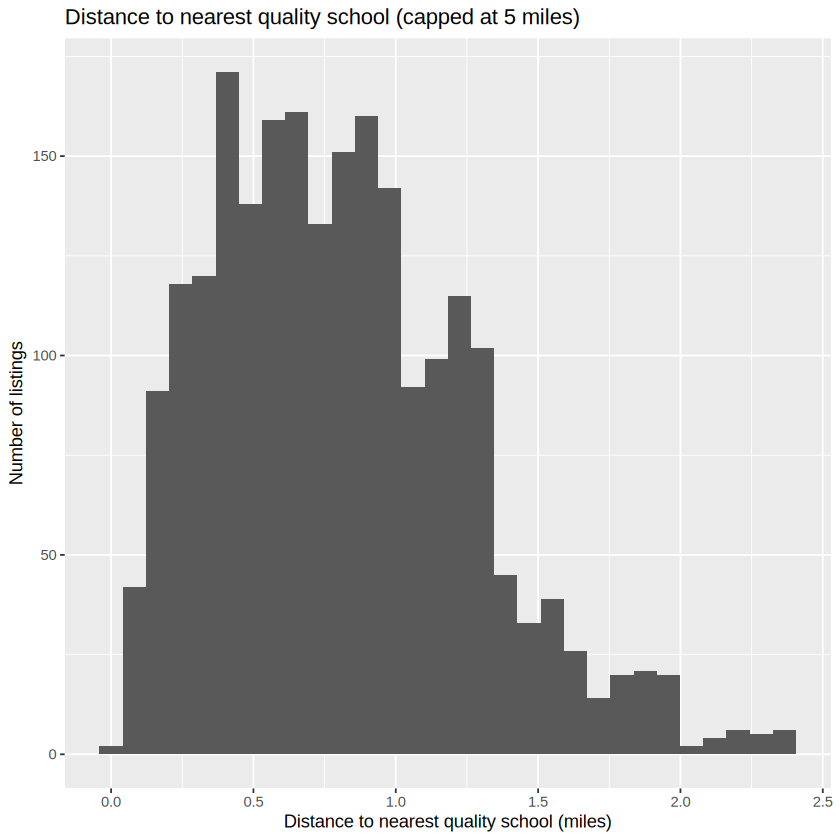

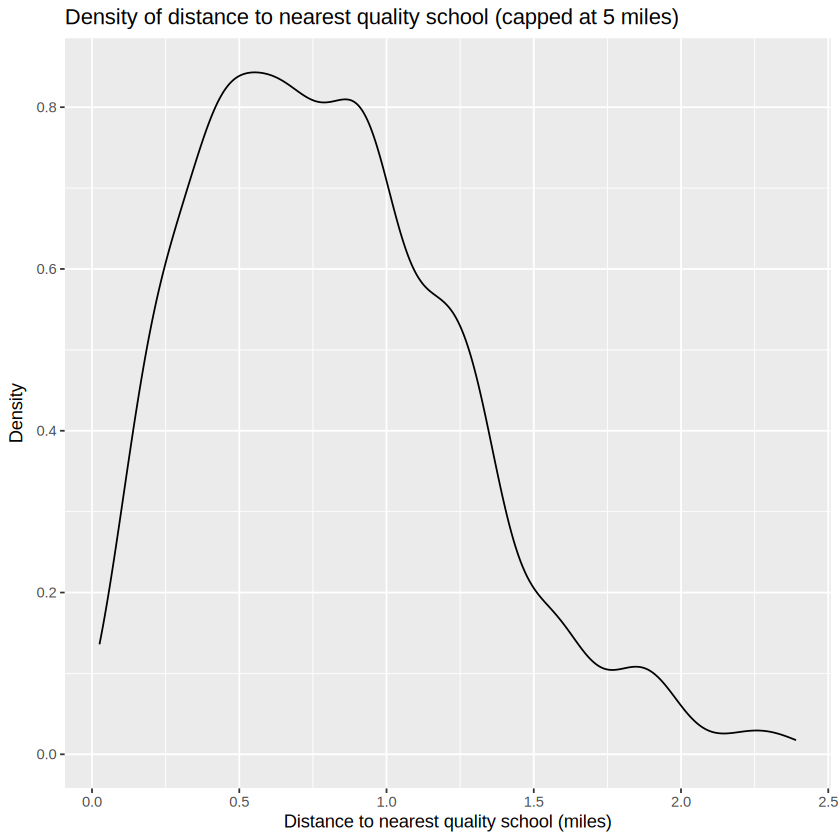

In [28]:
library(dplyr)
library(ggplot2)

# Filter out NAs, and maybe cap at, say, 5 miles to avoid extreme tails
dist_data <- homes_df %>%
  filter(!is.na(distance_to_quality_school_miles)) %>%
  mutate(
    distance_capped = pmin(distance_to_quality_school_miles, 5)
  )

# 1) Histogram
ggplot(dist_data, aes(x = distance_capped)) +
  geom_histogram(bins = 30) +
  labs(
    title = "Distance to nearest quality school (capped at 5 miles)",
    x = "Distance to nearest quality school (miles)",
    y = "Number of listings"
  )

# 2) Density plot
ggplot(dist_data, aes(x = distance_capped)) +
  geom_density() +
  labs(
    title = "Density of distance to nearest quality school (capped at 5 miles)",
    x = "Distance to nearest quality school (miles)",
    y = "Density"
  )


In [29]:
library(dplyr)
library(readr)

homes_df <- homes_df %>%
  mutate(
    price_num = readr::parse_number(as.character(PRICE))
  )

# Quick check
summary(homes_df$price_num)



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1000  620000  901000 1167915 1405000 8500000 

In [30]:
homes_df %>%
  summarise(
    n_homes                  = n(),
    median_price_all         = median(price_num, na.rm = TRUE),
    median_price_0_5         = median(price_num[within_0_5_mile_quality_school == 1], na.rm = TRUE),
    median_price_not_0_5     = median(price_num[within_0_5_mile_quality_school == 0], na.rm = TRUE),
    median_price_1_mile      = median(price_num[within_1_mile_quality_school == 1], na.rm = TRUE),
    median_price_not_1_mile  = median(price_num[within_1_mile_quality_school == 0], na.rm = TRUE)
  )


n_homes,median_price_all,median_price_0_5,median_price_not_0_5,median_price_1_mile,median_price_not_1_mile
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2237,901000,1105000,850000,969500,820000


In [31]:
library(dplyr)

homes_df_dist <- homes_df %>%
  filter(!is.na(distance_to_quality_school_miles), !is.na(price_num)) %>%
  mutate(
    dist_band = cut(
      distance_to_quality_school_miles,
      breaks = c(0, 0.25, 0.5, 1, 2, Inf),
      labels = c("0–0.25 mi", "0.25–0.5 mi", "0.5–1 mi", "1–2 mi", "2+ mi"),
      right = TRUE
    )
  )


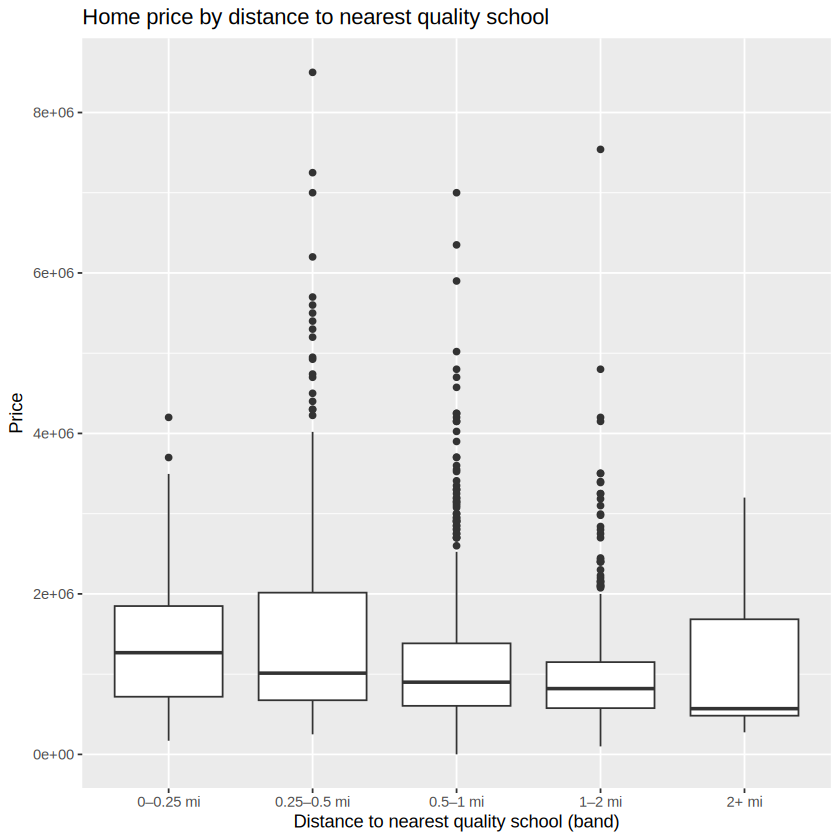

In [32]:
library(ggplot2)

ggplot(homes_df_dist, aes(x = dist_band, y = price_num)) +
  geom_boxplot() +
  labs(
    title = "Home price by distance to nearest quality school",
    x = "Distance to nearest quality school (band)",
    y = "Price"
  )


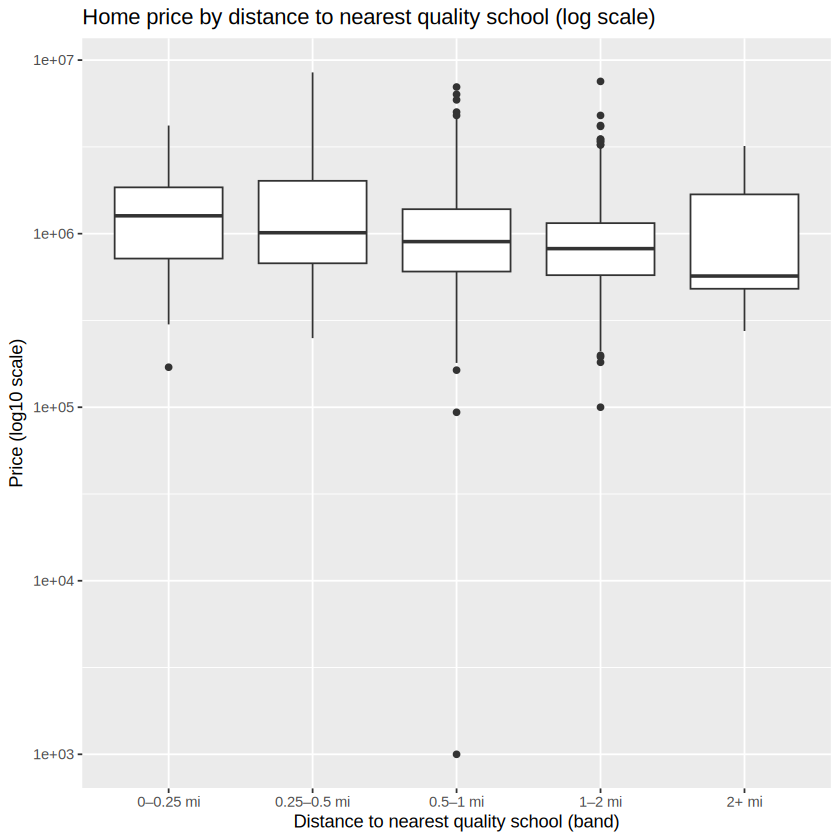

In [33]:
ggplot(homes_df_dist, aes(x = dist_band, y = price_num)) +
  geom_boxplot() +
  scale_y_log10() +
  labs(
    title = "Home price by distance to nearest quality school (log scale)",
    x = "Distance to nearest quality school (band)",
    y = "Price (log10 scale)"
  )


In [34]:
band_summary <- homes_df_dist %>%
  group_by(dist_band) %>%
  summarise(
    n            = n(),
    median_price = median(price_num, na.rm = TRUE),
    mean_price   = mean(price_num, na.rm = TRUE),
    .groups = "drop"
  )

band_summary


dist_band,n,median_price,mean_price
<fct>,<int>,<dbl>,<dbl>
0–0.25 mi,206,1267500,1383351.7
0.25–0.5 mi,418,1012500,1496732.9
0.5–1 mi,932,900000,1117574.3
1–2 mi,658,820000,967518.1
2+ mi,23,570000,1035452.2


dist_band,n,median_price,median_price_k
<fct>,<int>,<dbl>,<dbl>
0–0.25 mi,206,1267500,1267.5
0.25–0.5 mi,418,1012500,1012.5
0.5–1 mi,932,900000,900.0
1–2 mi,658,820000,820.0
2+ mi,23,570000,570.0


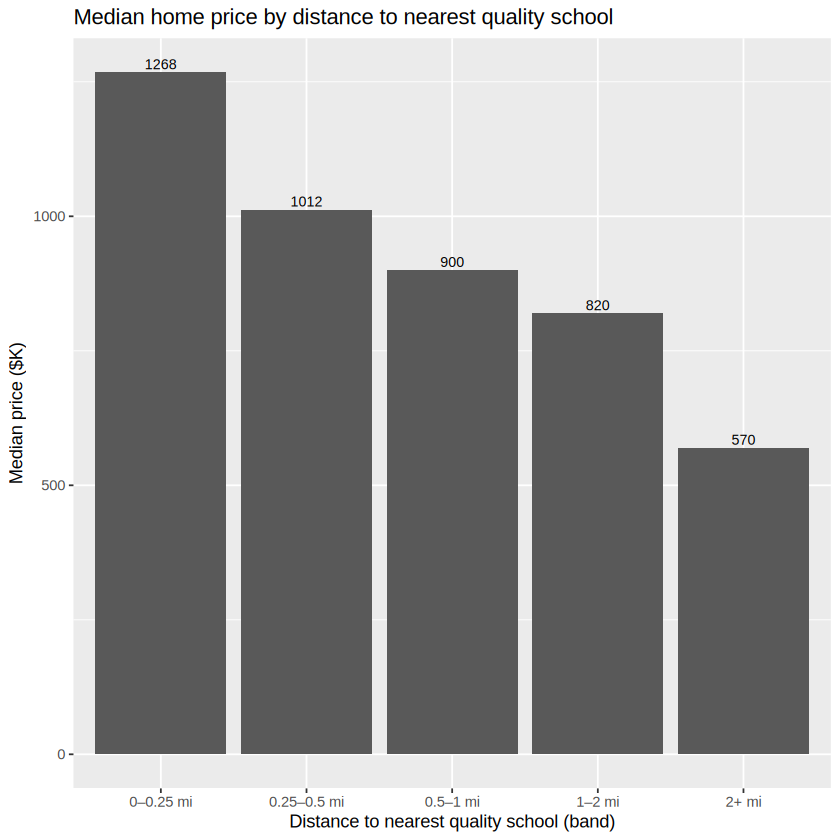

In [35]:
library(dplyr)
library(ggplot2)

# If you already have homes_df_dist from before, you can skip this block
homes_df_dist <- homes_df %>%
  filter(!is.na(distance_to_quality_school_miles), !is.na(price_num)) %>%
  mutate(
    dist_band = cut(
      distance_to_quality_school_miles,
      breaks = c(0, 0.25, 0.5, 1, 2, Inf),
      labels = c("0–0.25 mi", "0.25–0.5 mi", "0.5–1 mi", "1–2 mi", "2+ mi"),
      right = TRUE
    )
  )

band_summary <- homes_df_dist %>%
  group_by(dist_band) %>%
  summarise(
    n            = n(),
    median_price = median(price_num, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    median_price_k = median_price / 1000   # in thousands
  )

band_summary

ggplot(band_summary, aes(x = dist_band, y = median_price_k)) +
  geom_col() +
  geom_text(
    aes(label = round(median_price_k)),
    vjust = -0.3,
    size = 3
  ) +
  labs(
    title = "Median home price by distance to nearest quality school",
    x = "Distance to nearest quality school (band)",
    y = "Median price ($K)"
  )


# Amenities proximity calc



In [36]:
library(tidyverse)

amenities <- tribble(
  ~name,                                   ~category,         ~address,
  # Groceries (WF, TJ, Costco all together)
  "Whole Foods - Telegraph",               "grocery",         "5110 Telegraph Ave, Oakland, CA 94609",
  "Whole Foods - Lake Merritt",            "grocery",         "230 Bay Pl, Oakland, CA 94612",
  "Trader Joe's - Lakeshore",              "grocery",         "3250 Lakeshore Ave, Oakland, CA 94610",
  "Trader Joe's - Rockridge",              "grocery",         "5727 College Ave, Oakland, CA 94618",
  "Costco - Richmond",                     "grocery",         "4801 Central Ave, Richmond, CA 94804",
  "Costco - San Leandro",                  "grocery",         "1900 Davis St, San Leandro, CA 94577",

  # Major retail/dining clusters
  "Montclair Village",                     "retail_dining",   "1963 Mountain Blvd, Oakland, CA 94611",
  "Rockridge Commercial Strip",            "retail_dining",   "College Ave & Claremont Ave, Oakland, CA 94618",
  "Temescal District",                     "retail_dining",   "4701 Telegraph Ave, Oakland, CA",
  "Grand Ave / Grand Lake District",       "retail_dining",   "3200 Grand Ave, Oakland, CA 94610",
  "Lakeshore District",                    "retail_dining",   "3300 Lakeshore Ave, Oakland, CA 94610",

  # Shopping centers (including Target)
  "Bayfair Center",                        "shopping_center", "15555 E 14th St, San Leandro, CA 94578",
  "Bay Street Emeryville",                 "shopping_center", "5614 Bay St, Emeryville, CA 94608",
  "Target - Broadway Oakland",             "shopping_center", "2550 Broadway, Oakland, CA 94612",
  "Target - Alameda",                      "shopping_center", "2700 5th St, Alameda, CA 94501",

  # Hiking / Oakland hills
  "Redwood Regional - Skyline Gate",       "hiking",          "8490 Skyline Blvd, Oakland, CA 94611",
  "Joaquin Miller Park",                   "hiking",          "3450 Joaquin Miller Rd, Oakland, CA 94602",

  # Waterfronts
  "Jack London Square Waterfront",         "waterfront",      "98 Broadway, Oakland, CA 94607",

  # Employers (office + industrial all together)
  "Pixar Animation Studios",               "employer",        "1200 Park Ave, Emeryville, CA 94608",
  "PG&E HQ",                               "employer",        "300 Lakeside Dr, Oakland, CA 94612",
  "Port of Oakland - Seaport",             "employer",        "530 Water St, Oakland, CA 94607",
  "Oakland Int'l Airport & Cargo (OAK)",   "employer",        "1 Airport Dr, Oakland, CA 94621",
  "Oakland Global Trade & Logistics Hub",  "employer",        "2400 W 7th St, Oakland, CA 94607",
  "Tesla Fremont Factory",                 "employer",        "45500 Fremont Blvd, Fremont, CA 94538"
)


In [37]:
install.packages("tidygeocoder")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [38]:
library(tidygeocoder)

amenities_geo <- amenities %>%
  geocode(address, method = "osm", lat = latitude, long = longitude)

amenities_geo


Warning message:
“package ‘tidygeocoder’ was built under R version 4.5.2”
Passing 24 addresses to the Nominatim single address geocoder

Query completed in: 43.6 seconds



name,category,address,latitude,longitude
<chr>,<chr>,<chr>,<dbl>,<dbl>
Whole Foods - Telegraph,grocery,"5110 Telegraph Ave, Oakland, CA 94609",37.83752,-122.2616
Whole Foods - Lake Merritt,grocery,"230 Bay Pl, Oakland, CA 94612",37.81309,-122.2607
Trader Joe's - Lakeshore,grocery,"3250 Lakeshore Ave, Oakland, CA 94610",37.80979,-122.2443
Trader Joe's - Rockridge,grocery,"5727 College Ave, Oakland, CA 94618",37.84554,-122.2526
Costco - Richmond,grocery,"4801 Central Ave, Richmond, CA 94804",37.89884,-122.3202
Costco - San Leandro,grocery,"1900 Davis St, San Leandro, CA 94577",37.72081,-122.1819
Montclair Village,retail_dining,"1963 Mountain Blvd, Oakland, CA 94611",37.82801,-122.2105
Rockridge Commercial Strip,retail_dining,"College Ave & Claremont Ave, Oakland, CA 94618",37.84877,-122.2523
Temescal District,retail_dining,"4701 Telegraph Ave, Oakland, CA",37.83448,-122.2633


In [39]:
library(sf)
library(dplyr)
library(purrr)

# 1) Convert homes_df to sf
homes_sf <- homes_df %>%
  st_as_sf(coords = c("LONGITUDE", "LATITUDE"), crs = 4326, remove = FALSE)

# 2) Convert amenities to sf
amenities_sf <- amenities_geo %>%
  st_as_sf(coords = c("longitude", "latitude"), crs = 4326, remove = FALSE)

# Helper: compute minimum distance (in miles) from each home to any amenity in a category
dist_to_category <- function(category_name) {
  cat_points <- amenities_sf %>% filter(category == category_name)

  # st_distance returns a matrix of distances in meters
  dmat <- st_distance(homes_sf, cat_points)  # homes x amenities

  # Take min distance per home, convert meters to miles
  min_meters <- apply(dmat, 1, min)
  min_miles  <- as.numeric(min_meters) / 1609.34

  tibble(!!paste0("dist_to_", category_name, "_miles") := min_miles)
}

# List of categories to create columns for
cats <- c("grocery", "retail_dining", "shopping_center", "hiking", "waterfront", "employer")

# 3) Build a tibble of all distance columns
dist_cols <- map_dfc(cats, dist_to_category)

# 4) Bind back to homes_df
homes_df_with_amenities <- bind_cols(homes_df, dist_cols)


In [40]:
homes_df <- homes_df_with_amenities
colnames(homes_df)


[1] "SALE TYPE"                                                                                  
 [2] "SOLD DATE"                                                                                  
 [3] "PROPERTY TYPE"                                                                              
 [4] "ADDRESS"                                                                                    
 [5] "CITY"                                                                                       
 [6] "STATE OR PROVINCE"                                                                          
 [7] "ZIP OR POSTAL CODE"                                                                         
 [8] "PRICE"                                                                                      
 [9] "BEDS"                                                                                       
[10] "BATHS"                                                                                      
[11] "LOCATION"                                                                                   
[12] "SQUARE FEET"                                                                                
[13] "LOT SIZE"                                                                                   
[14] "YEAR BUILT"                                                                                 
[15] "DAYS ON MARKET"                                                                             
[16] "$/SQUARE FEET"                                                                              
[17] "HOA/MONTH"                                                                                  
[18] "STATUS"                                                                                     
[19] "NEXT OPEN HOUSE START TIME"                                                                 
[20] "NEXT OPEN HOUSE END TIME"                                                                   
[21] "URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR INFO ON PRICING)"
[22] "SOURCE"                                                                                     
[23] "MLS#"                                                                                       
[24] "FAVORITE"                                                                                   
[25] "INTERESTED"                                                                                 
[26] "LATITUDE"                                                                                   
[27] "LONGITUDE"                                                                                  
[28] "distance_to_bart_miles"                                                                     
[29] "within_0_5_miles_bart"                                                                      
[30] "distance_to_quality_school_miles"                                                           
[31] "nearest_quality_school_name"                                                                
[32] "nearest_quality_school_quality_distance"                                                    
[33] "nearest_quality_school_quality_level"                                                       
[34] "within_2_miles_quality_school"                                                              
[35] "within_0_5_mile_quality_school"                                                             
[36] "within_1_mile_quality_school"                                                               
[37] "price_num"                                                                                  
[38] "dist_to_grocery_miles"                                                                      
[39] "dist_to_retail_dining_miles"                                                                
[40] "dist_to_shopping_center_miles"                                                              
[41] "dist_to_hiking_miles"              

In [41]:
set.seed(123)  # for reproducibility, optional

homes_df %>%
  dplyr::slice_sample(n = 10) %>%              # grab 10 random listings
  dplyr::select(
    ADDRESS, CITY, PRICE,                      # core listing info (adjust to your cols)
    LATITUDE, LONGITUDE,
    dplyr::starts_with("dist_to_")            # all the new amenity distance columns
  )


ADDRESS,CITY,PRICE,LATITUDE,LONGITUDE,dist_to_grocery_miles,dist_to_retail_dining_miles,dist_to_shopping_center_miles,dist_to_hiking_miles,dist_to_waterfront_miles,dist_to_employer_miles
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
402 Hiller Dr,Oakland,925000,37.85368,-122.2262,1.5454525,1.4628948,3.434357,0.6494815,4.897004,3.4552701
1116 16th St,Oakland,876000,37.81114,-122.2850,1.3342641,2.0011588,1.117339,4.8360853,1.223272,0.6830598
2033 Harrington Ave,Oakland,195000,37.78199,-122.2155,2.4810784,2.5102953,3.516980,2.4857342,3.435385,3.2331619
6258 Boulder Ln #4801,Oakland,795000,37.77953,-122.1646,4.1660273,4.1855013,5.846700,2.3821367,6.190523,4.8174156
1009 Winsor Ave,Piedmont,2100000,37.81640,-122.2373,0.5950197,0.5484011,1.520343,2.8310480,2.598023,1.5538472
4614 Rockingham Ct,Oakland,4800000,37.78582,-122.1643,4.5929097,3.8561336,5.845823,2.0245945,6.145203,5.2120908
868 44th St,Emeryville,1175000,37.83381,-122.2722,0.6339907,0.4862456,1.072749,3.4334778,2.701295,0.6323802
9057 Skyline Blvd,Oakland,2400000,37.82622,-122.1891,3.2174252,1.1764824,4.221517,1.1667697,5.228566,4.2645979
6907 Chambers Dr,Oakland,965000,37.83621,-122.1990,2.9936298,0.8455159,3.900040,1.4480853,5.092782,4.0227361


# HOLC Zone Calc


In [42]:
library(sf)
library(dplyr)

# --- 0. Make sure both layers use the same CRS (WGS84 / 4326) ---

# If oakland_sf_valid is already 4326, this is a no-op but safe:
oakland_sf_valid <- st_transform(oakland_sf_valid, 4326)

# Homes as sf points (you already used this pattern before)
homes_sf <- homes_df %>%
  st_as_sf(coords = c("LONGITUDE", "LATITUDE"),
           crs = 4326,
           remove = FALSE)

# --- 1. Keep only the HOLC grade from the polygons ---

oakland_zones <- oakland_sf_valid %>%
  select(grade)  # 'grade' is the A/B/C/D column

# --- 2. Spatial join: assign each listing the HOLC grade of the polygon it falls in ---

homes_with_holc_sf <- st_join(
  homes_sf,
  oakland_zones,
  join = st_within,  # point-in-polygon
  left = TRUE        # keep all homes; grade will be NA if outside any zone
)

# --- 3. Map grade -> color and drop geometry back to a regular data frame ---

holc_colors <- c("A" = "green", "B" = "blue", "C" = "yellow", "D" = "red")

homes_df <- homes_with_holc_sf %>%
  st_drop_geometry() %>%
  mutate(
    holc_grade = grade,  # rename for clarity
    holc_grade = factor(holc_grade, levels = c("A", "B", "C", "D")),
    holc_color = holc_colors[as.character(holc_grade)]
  )


In [43]:
# How many listings in each HOLC grade?
homes_df %>% count(holc_grade)

# Peek at random listings with their HOLC tag + distances
set.seed(123)
homes_df %>%
  slice_sample(n = 10) %>%
  select(ADDRESS, CITY, holc_grade, holc_color, starts_with("dist_to_"))


holc_grade,n
<fct>,<int>
A,275
B,452
C,669
D,402
NA,439


ADDRESS,CITY,holc_grade,holc_color,dist_to_grocery_miles,dist_to_retail_dining_miles,dist_to_shopping_center_miles,dist_to_hiking_miles,dist_to_waterfront_miles,dist_to_employer_miles
<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
402 Hiller Dr,Oakland,NA,NA,1.5454525,1.4628948,3.434357,0.6494815,4.897004,3.4552701
1116 16th St,Oakland,D,red,1.3342641,2.0011588,1.117339,4.8360853,1.223272,0.6830598
2033 Harrington Ave,Oakland,C,yellow,2.4810784,2.5102953,3.516980,2.4857342,3.435385,3.2331619
6258 Boulder Ln #4801,Oakland,NA,NA,4.1660273,4.1855013,5.846700,2.3821367,6.190523,4.8174156
1009 Winsor Ave,Piedmont,B,blue,0.5950197,0.5484011,1.520343,2.8310480,2.598023,1.5538472
4614 Rockingham Ct,Oakland,NA,NA,4.5929097,3.8561336,5.845823,2.0245945,6.145203,5.2120908
868 44th St,Emeryville,D,red,0.6339907,0.4862456,1.072749,3.4334778,2.701295,0.6323802
9057 Skyline Blvd,Oakland,A,green,3.2174252,1.1764824,4.221517,1.1667697,5.228566,4.2645979
6907 Chambers Dr,Oakland,A,green,2.9936298,0.8455159,3.900040,1.4480853,5.092782,4.0227361


In [44]:
library(dplyr)

homes_df <- homes_df %>%
  mutate(
    # Grade-based dummies
    is_HOLC_A = if_else(holc_grade == "A", 1L, 0L, missing = 0L),
    is_HOLC_B = if_else(holc_grade == "B", 1L, 0L, missing = 0L),
    is_HOLC_C = if_else(holc_grade == "C", 1L, 0L, missing = 0L),
    is_HOLC_D = if_else(holc_grade == "D", 1L, 0L, missing = 0L),

    # Color-based dummy for “redlined” (HOLC D)
    is_HOLC_red = if_else(holc_color == "red", 1L, 0L, missing = 0L)
  )


In [45]:
homes_df %>%
  count(holc_grade, is_HOLC_red)


holc_grade,is_HOLC_red,n
<fct>,<int>,<int>
A,0,275
B,0,452
C,0,669
D,1,402
NA,0,439


# Sold Year Fixed Effect


In [46]:
library(dplyr)
library(lubridate)

homes_df <- homes_df %>%
  mutate(
    sale_date = mdy(`SOLD DATE`),      # parse "SOLD DATE" column
    sale_year = year(sale_date)        # extract year
  )


In [47]:
homes_df <- homes_df %>%
  mutate(
    sale_year = factor(sale_year)
  )


In [48]:
table(homes_df$sale_year)



2020 2021 2022 2023 2024 2025 
  89  636  400  265  256  240 

In [49]:
library(dplyr)

homes_df <- homes_df %>%
  mutate(
    # 1) Clean year built into numeric
    year_built = as.numeric(`YEAR BUILT`),

    # 2) Make sure sale_year is numeric (not factor) for the calc
    sale_year_num = as.numeric(as.character(sale_year)),

    # 3) Age of house at time of sale
    age_at_sale = sale_year_num - year_built
  )


In [50]:
homes_df %>%
  select(`YEAR BUILT`, year_built, sale_year, sale_year_num, age_at_sale) %>%
  head()


YEAR BUILT,year_built,sale_year,sale_year_num,age_at_sale
<dbl>,<dbl>,<fct>,<dbl>,<dbl>
1928,1928,2023,2023,95
1955,1955,2022,2022,67
1925,1925,NA,NA,NA
1996,1996,NA,NA,NA
1928,1928,NA,NA,NA
1951,1951,2022,2022,71


# LASSO

In [51]:
library(dplyr)
library(purrr)

# Quick glance
glimpse(homes_df)

# Data dictionary style summary
var_summary <- tibble(
  variable   = names(homes_df),
  class      = map_chr(homes_df, ~ paste(class(.x), collapse = ", ")),
  n_missing  = map_int(homes_df, ~ sum(is.na(.x)))
)

var_summary


Rows: 2,237
Columns: 56
$ `SALE TYPE`                                                                                   <chr> …
$ `SOLD DATE`                                                                                   <chr> …
$ `PROPERTY TYPE`                                                                               <chr> …
$ ADDRESS                                                                                       <chr> …
$ CITY                                                                                          <chr> …
$ `STATE OR PROVINCE`                                                                           <chr> …
$ `ZIP OR POSTAL CODE`                                                                          <dbl> …
$ PRICE                                                                                         <dbl> …
$ BEDS                                                                                          <dbl> …
$ BATHS                                 

variable,class,n_missing
<chr>,<chr>,<int>
SALE TYPE,character,0
SOLD DATE,character,351
PROPERTY TYPE,character,0
ADDRESS,character,0
CITY,character,0
STATE OR PROVINCE,character,0
ZIP OR POSTAL CODE,numeric,0
PRICE,numeric,0
BEDS,numeric,13


In [52]:
library(dplyr)
library(glmnet)

model_df <- homes_df %>%
  select(
    PRICE,
    BEDS,
    BATHS,
    `SQUARE FEET`,
    age_at_sale,
    distance_to_bart_miles,
    within_0_5_miles_bart,
    distance_to_quality_school_miles,
    within_0_5_mile_quality_school,
    dist_to_grocery_miles,
    dist_to_retail_dining_miles,
    dist_to_shopping_center_miles,
    dist_to_hiking_miles,
    dist_to_waterfront_miles,
    dist_to_employer_miles,
    is_HOLC_A,
    is_HOLC_B,
    is_HOLC_D,
    sale_year
    # (note: not including is_HOLC_red to avoid redundancy with is_HOLC_D)
  ) %>%
  tidyr::drop_na() %>%          # drop rows with any missing values in these cols
  mutate(
    log_price = log(PRICE),
    sale_year = factor(sale_year)   # make sure year is a factor for FE
  )


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-10



In [53]:
# Model matrix: glmnet wants a numeric matrix for X
x <- model.matrix(
  log_price ~
    BEDS +
    BATHS + 
    `SQUARE FEET` +
    age_at_sale +
    distance_to_bart_miles +
    within_0_5_miles_bart +
    distance_to_quality_school_miles +
    within_0_5_mile_quality_school +
    dist_to_grocery_miles +
    dist_to_retail_dining_miles +
    dist_to_shopping_center_miles +
    dist_to_hiking_miles +
    dist_to_waterfront_miles +
    dist_to_employer_miles +
    is_HOLC_A + is_HOLC_B + is_HOLC_D +
    sale_year,     # year fixed effects via dummies
  data = model_df
)

# Drop intercept column (first col)
x <- x[, -1]

# Outcome
y <- model_df$log_price


In [54]:
set.seed(123)

lasso_cv <- cv.glmnet(
  x, y,
  alpha = 1,         # LASSO
  nfolds = 10        # CV folds
)

# Best lambda (min CV error)
lasso_cv$lambda.min

# Slightly more regularized (1-SE rule)
lasso_cv$lambda.1se


[1] 0.0004005349

[1] 0.07332746

In [55]:
coef_min <- coef(lasso_cv, s = "lambda.min")
coef_min


23 x 1 sparse Matrix of class "dgCMatrix"
                                    lambda.min
(Intercept)                      13.0386136860
BEDS                              0.0349805425
BATHS                             0.0632555248
`SQUARE FEET`                     0.0002896306
age_at_sale                       0.0007388426
distance_to_bart_miles            0.0355756236
within_0_5_miles_bart             0.1056523571
distance_to_quality_school_miles  0.0552447879
within_0_5_mile_quality_school    0.0959232339
dist_to_grocery_miles            -0.0206501056
dist_to_retail_dining_miles      -0.0688570485
dist_to_shopping_center_miles    -0.1258724725
dist_to_hiking_miles             -0.0542825700
dist_to_waterfront_miles          0.0667820292
dist_to_employer_miles            0.0723559254
is_HOLC_A                         0.0719049052
is_HOLC_B                         0.1154687301
is_HOLC_D                        -0.0364422243
sale_year2021                     0.0850193222
sale_year2022     

In [56]:
library(tibble)

coef_tbl <- coef_min %>%
  as.matrix() %>%
  as.data.frame() %>%
  rownames_to_column("variable") %>%
  rename(coefficient = 2) %>%
  as_tibble()

# Non-zero coefficients only
coef_tbl %>%
  filter(coefficient != 0)


variable,coefficient
<chr>,<dbl>
(Intercept),13.0386136860
BEDS,0.0349805425
BATHS,0.0632555248
`SQUARE FEET`,0.0002896306
age_at_sale,0.0007388426
distance_to_bart_miles,0.0355756236
within_0_5_miles_bart,0.1056523571
distance_to_quality_school_miles,0.0552447879
within_0_5_mile_quality_school,0.0959232339


In [57]:
library(tibble)
library(dplyr)

# Coefficients at lambda.min
coef_min <- coef(lasso_cv, s = "lambda.min")

coef_tbl <- coef_min %>%
  as.matrix() %>%
  as.data.frame() %>%
  rownames_to_column("variable") %>%
  rename(coefficient = 2) %>%
  as_tibble()

# Separate intercept
intercept <- coef_tbl %>%
  filter(variable == "(Intercept)")

# Variables kept (non-zero, excluding intercept)
vars_kept <- coef_tbl %>%
  filter(variable != "(Intercept)",
         coefficient != 0)

# Variables removed (exactly zero)
vars_removed <- coef_tbl %>%
  filter(variable != "(Intercept)",
         coefficient == 0)

# View them
vars_kept
vars_removed
intercept


variable,coefficient
<chr>,<dbl>
BEDS,0.0349805425
BATHS,0.0632555248
`SQUARE FEET`,0.0002896306
age_at_sale,0.0007388426
distance_to_bart_miles,0.0355756236
within_0_5_miles_bart,0.1056523571
distance_to_quality_school_miles,0.0552447879
within_0_5_mile_quality_school,0.0959232339
dist_to_grocery_miles,-0.0206501056


variable,coefficient
<chr>,<dbl>


variable,coefficient
<chr>,<dbl>
(Intercept),13.03861


In [58]:
library(dplyr)
library(tibble)
library(stringr)

# Coefficients from LASSO at lambda.min
coef_min <- coef(lasso_cv, s = "lambda.min")

coef_tbl <- coef_min %>%
  as.matrix() %>%
  as.data.frame() %>%
  rownames_to_column("variable") %>%
  rename(coefficient = 2) %>%
  as_tibble()

# Remove intercept, add absolute value, sort by |coef|
coef_sorted <- coef_tbl %>%
  filter(variable != "(Intercept)") %>%
  mutate(abs_coef = abs(coefficient)) %>%
  arrange(desc(abs_coef))

# Look at the top 10 to sanity check
coef_sorted %>% head(22)


variable,coefficient,abs_coef
<chr>,<dbl>,<dbl>
dist_to_shopping_center_miles,-0.1258724725,0.1258724725
is_HOLC_B,0.1154687301,0.1154687301
within_0_5_miles_bart,0.1056523571,0.1056523571
sale_year2022,0.0967316359,0.0967316359
within_0_5_mile_quality_school,0.0959232339,0.0959232339
sale_year2021,0.0850193222,0.0850193222
dist_to_employer_miles,0.0723559254,0.0723559254
is_HOLC_A,0.0719049052,0.0719049052
dist_to_retail_dining_miles,-0.0688570485,0.0688570485


In [93]:
model_ols <- lm(
  log(PRICE) ~ BATHS + BEDS + is_HOLC_A + is_HOLC_B + is_HOLC_D + within_0_5_mile_quality_school + `SQUARE FEET` +
    dist_to_employer_miles + dist_to_shopping_center_miles +
    sale_year,
  data = homes_df
)

summary(model_ols)



Call:
lm(formula = log(PRICE) ~ BATHS + BEDS + is_HOLC_A + is_HOLC_B + 
    is_HOLC_D + within_0_5_mile_quality_school + `SQUARE FEET` + 
    dist_to_employer_miles + dist_to_shopping_center_miles + 
    sale_year, data = homes_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.4883 -0.1815  0.0114  0.2035  0.9234 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     1.301e+01  4.541e-02 286.446  < 2e-16 ***
BATHS                           4.431e-02  1.398e-02   3.168  0.00156 ** 
BEDS                            4.663e-02  9.749e-03   4.783 1.86e-06 ***
is_HOLC_A                       2.424e-01  2.712e-02   8.939  < 2e-16 ***
is_HOLC_B                       1.791e-01  2.179e-02   8.222 3.71e-16 ***
is_HOLC_D                      -9.561e-02  2.421e-02  -3.948 8.16e-05 ***
within_0_5_mile_quality_school  7.504e-02  1.850e-02   4.056 5.19e-05 ***
`SQUARE FEET`                   3.153e-04  1.639e-05  19.233  < 2e

In [94]:
library(dplyr)

homes_df_plot <- homes_df %>%
  mutate(
    log_price_hat = predict(model_ols, newdata = homes_df),  # <- key change
    price_hat     = exp(log_price_hat),
    resid_log     = log(PRICE) - log_price_hat
  )


In [95]:
homes_df_plot_complete <- homes_df_plot %>%
  filter(!is.na(log_price_hat))


Warning message:
“Removed 361 rows containing missing values or values outside the scale range
(`geom_point()`).”


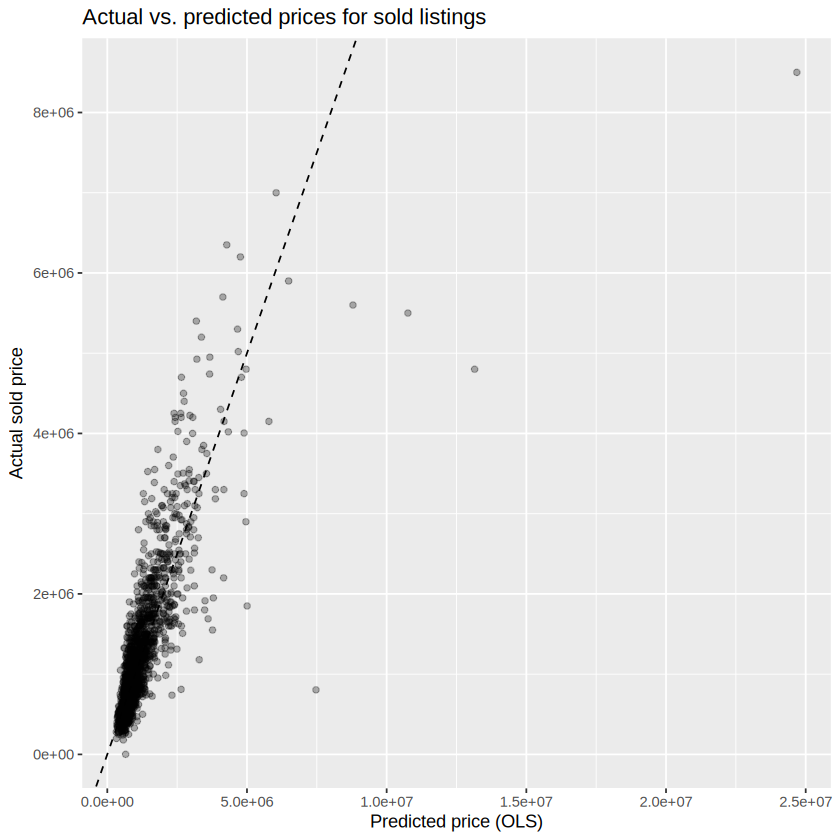

In [96]:
library(ggplot2)

ggplot(homes_df_plot, aes(x = price_hat, y = PRICE)) +
  geom_point(alpha = 0.3) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(
    x = "Predicted price (OLS)",
    y = "Actual sold price",
    title = "Actual vs. predicted prices for sold listings"
  )


Warning message:
“Removed 361 rows containing missing values or values outside the scale range
(`geom_point()`).”


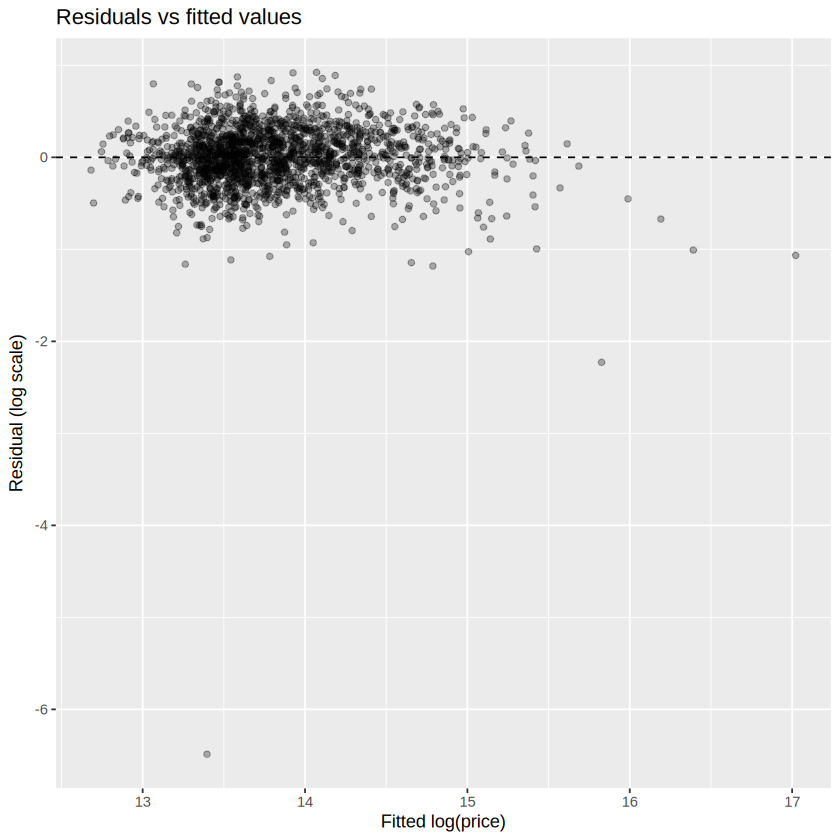

In [97]:
ggplot(homes_df_plot, aes(x = log_price_hat, y = resid_log)) +
  geom_point(alpha = 0.3) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    x = "Fitted log(price)",
    y = "Residual (log scale)",
    title = "Residuals vs fitted values"
  )


Warning message:
“Removed 361 rows containing missing values or values outside the scale range
(`geom_point()`).”


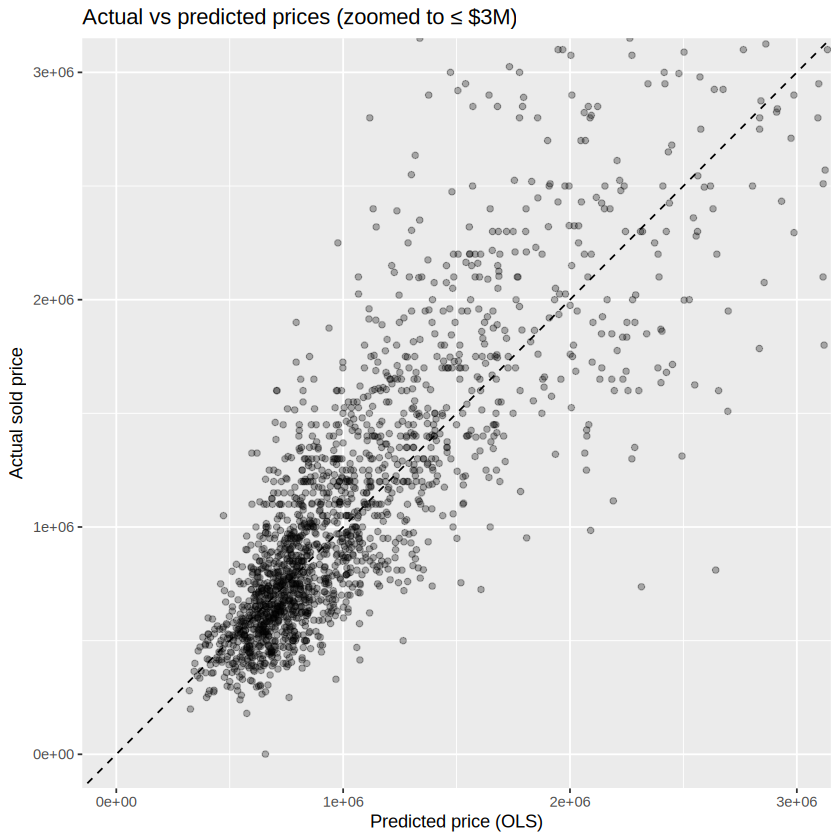

In [98]:
library(ggplot2)

ggplot(homes_df_plot, aes(x = price_hat, y = PRICE)) +
  geom_point(alpha = 0.3) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  coord_cartesian(xlim = c(0, 3e6), ylim = c(0, 3e6)) +
  labs(
    x = "Predicted price (OLS)",
    y = "Actual sold price",
    title = "Actual vs predicted prices (zoomed to ≤ $3M)"
  )


Warning message:
“Removed 361 rows containing missing values or values outside the scale range
(`geom_point()`).”


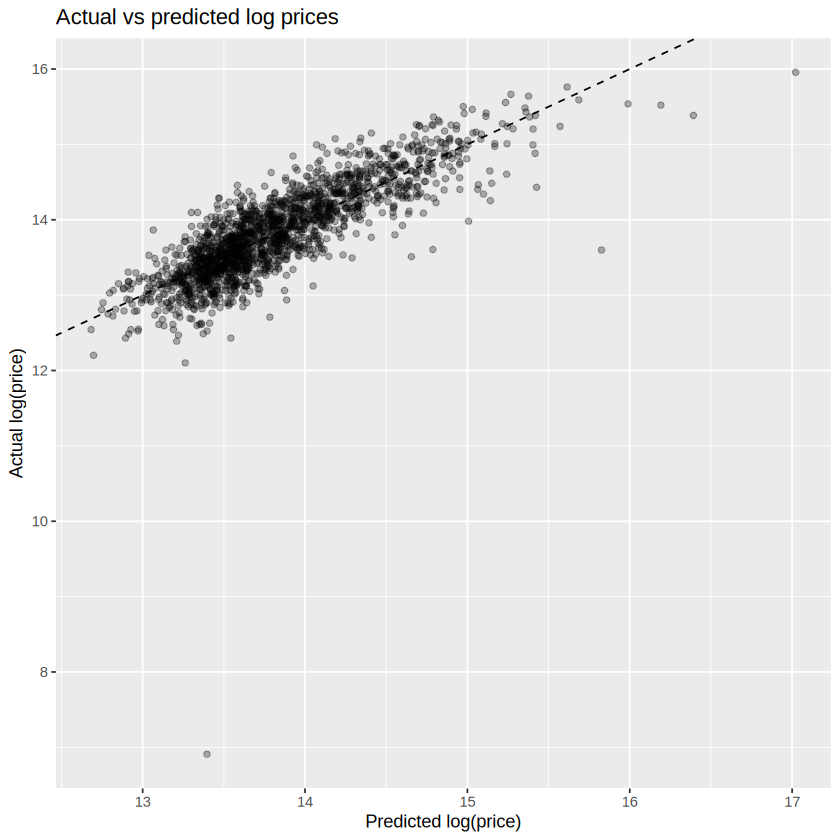

In [99]:
ggplot(homes_df_plot, aes(x = log_price_hat, y = log(PRICE))) +
  geom_point(alpha = 0.3) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(
    x = "Predicted log(price)",
    y = "Actual log(price)",
    title = "Actual vs predicted log prices"
  )


Warning message:
“Removed 361 rows containing missing values or values outside the scale range
(`geom_point()`).”


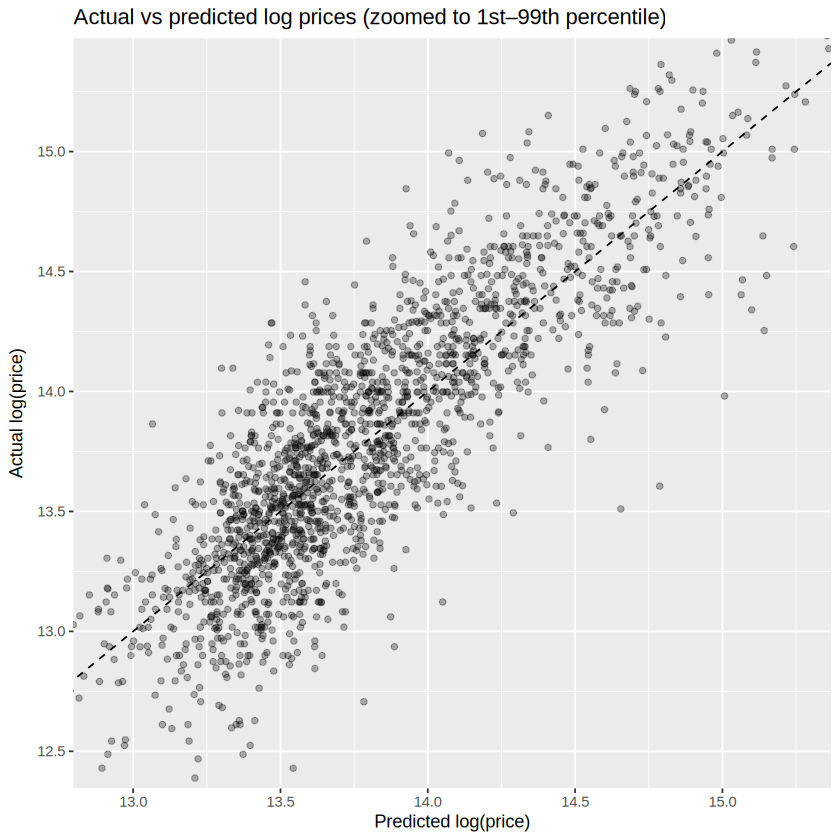

In [100]:
# compute central quantiles
x_q <- quantile(homes_df_plot$log_price_hat, probs = c(0.01, 0.99), na.rm = TRUE)
y_q <- quantile(log(homes_df_plot$PRICE),   probs = c(0.01, 0.99), na.rm = TRUE)

ggplot(homes_df_plot, aes(x = log_price_hat, y = log(PRICE))) +
  geom_point(alpha = 0.3) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  coord_cartesian(xlim = x_q, ylim = y_q) +
  labs(
    x = "Predicted log(price)",
    y = "Actual log(price)",
    title = "Actual vs predicted log prices (zoomed to 1st–99th percentile)"
  )


Warning message:
“Removed 361 rows containing missing values or values outside the scale range
(`geom_point()`).”


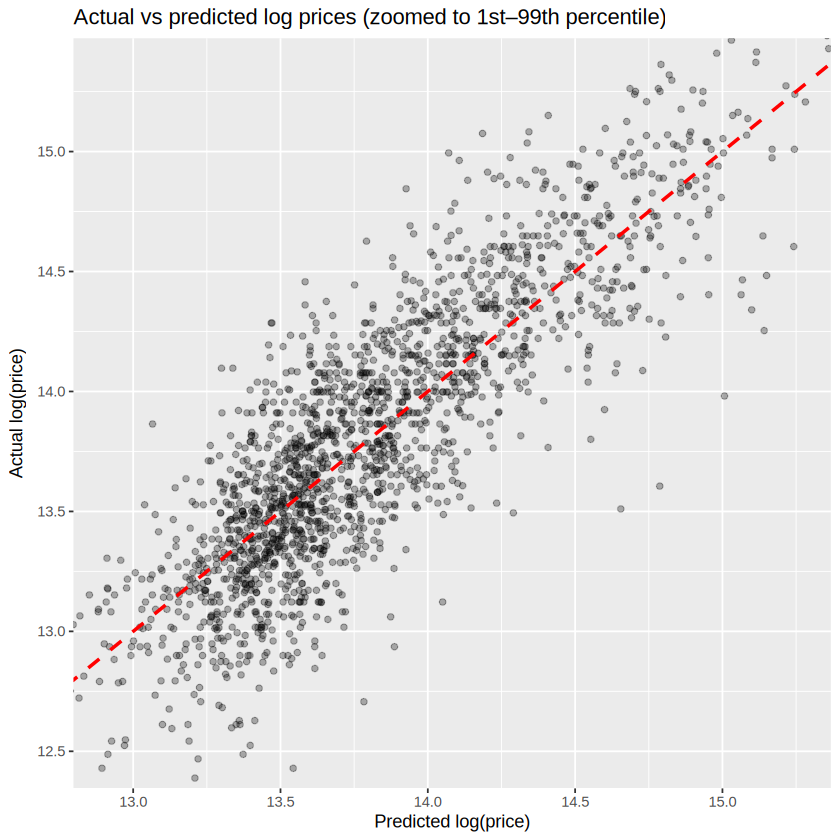

In [101]:
# compute central quantiles
x_q <- quantile(homes_df_plot$log_price_hat, probs = c(0.01, 0.99), na.rm = TRUE)
y_q <- quantile(log(homes_df_plot$PRICE),   probs = c(0.01, 0.99), na.rm = TRUE)

ggplot(homes_df_plot, aes(x = log_price_hat, y = log(PRICE))) +
  geom_point(alpha = 0.3) +
  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = "dashed",
    color = "red",      # ← make the 45° line red
    linewidth = 1
  ) +
  coord_cartesian(xlim = x_q, ylim = y_q) +
  labs(
    x = "Predicted log(price)",
    y = "Actual log(price)",
    title = "Actual vs predicted log prices (zoomed to 1st–99th percentile)"
  )


In [102]:
library(dplyr)
library(forcats)

homes_df <- homes_df %>%
  mutate(
    zip_code = as.factor(`ZIP OR POSTAL CODE`),   # turn it into a factor
    zip_code = fct_relevel(zip_code, "94609"),    # set 94609 as baseline
    sale_year = factor(sale_year)                 # keep year as factor for FE
  )


In [103]:
model_ols_zip <- lm(
  log(PRICE) ~ BATHS + BEDS + `SQUARE FEET` +
    is_HOLC_A + is_HOLC_B + is_HOLC_D +
    within_0_5_mile_quality_school +
    dist_to_employer_miles + dist_to_shopping_center_miles +
    sale_year + zip_code,    # ← zip fixed effects, 94609 is baseline
  data = homes_df
)

summary(model_ols_zip)



Call:
lm(formula = log(PRICE) ~ BATHS + BEDS + `SQUARE FEET` + is_HOLC_A + 
    is_HOLC_B + is_HOLC_D + within_0_5_mile_quality_school + 
    dist_to_employer_miles + dist_to_shopping_center_miles + 
    sale_year + zip_code, data = homes_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.6279 -0.1531  0.0244  0.1770  0.7707 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                    13.0164679  0.0542445 239.959  < 2e-16 ***
BATHS                           0.0281566  0.0132420   2.126 0.033611 *  
BEDS                            0.0636047  0.0093489   6.803 1.38e-11 ***
`SQUARE FEET`                   0.0002807  0.0000155  18.109  < 2e-16 ***
is_HOLC_A                       0.0142349  0.0319096   0.446 0.655578    
is_HOLC_B                       0.0736154  0.0225948   3.258 0.001142 ** 
is_HOLC_D                      -0.0135185  0.0272561  -0.496 0.619967    
within_0_5_mile_quality_school  0.0693158  0.0175187   

In [104]:
library(broom)
library(dplyr)
library(stringr)

zip_effects <- tidy(model_ols_zip) %>%
  filter(str_starts(term, "zip_code")) %>%           # only zip dummies
  mutate(
    zip_code = str_remove(term, "^zip_code"),        # pull out the zip
    pct_diff = (exp(estimate) - 1) * 100            # convert to % vs 94609
  ) %>%
  select(zip_code, estimate, pct_diff, std.error, p.value)

zip_effects


zip_code,estimate,pct_diff,std.error,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
94501,0.139664237,14.9887644,0.10781378,1.953375e-01
94560,-0.210562862,-18.9871873,0.32228977,5.136226e-01
94577,-0.206681243,-18.6721153,0.08355387,1.346453e-02
94601,-0.411492642,-33.7339603,0.05530853,1.537337e-13
94602,-0.017988807,-1.7827974,0.05277801,7.332636e-01
94603,-0.486028512,-38.4935730,0.05366684,3.347407e-19
94605,-0.350520247,-29.5678427,0.05832982,2.241067e-09
94606,-0.345494454,-29.2129742,0.05703659,1.673162e-09
94607,-0.199603031,-18.0944172,0.04977527,6.312305e-05


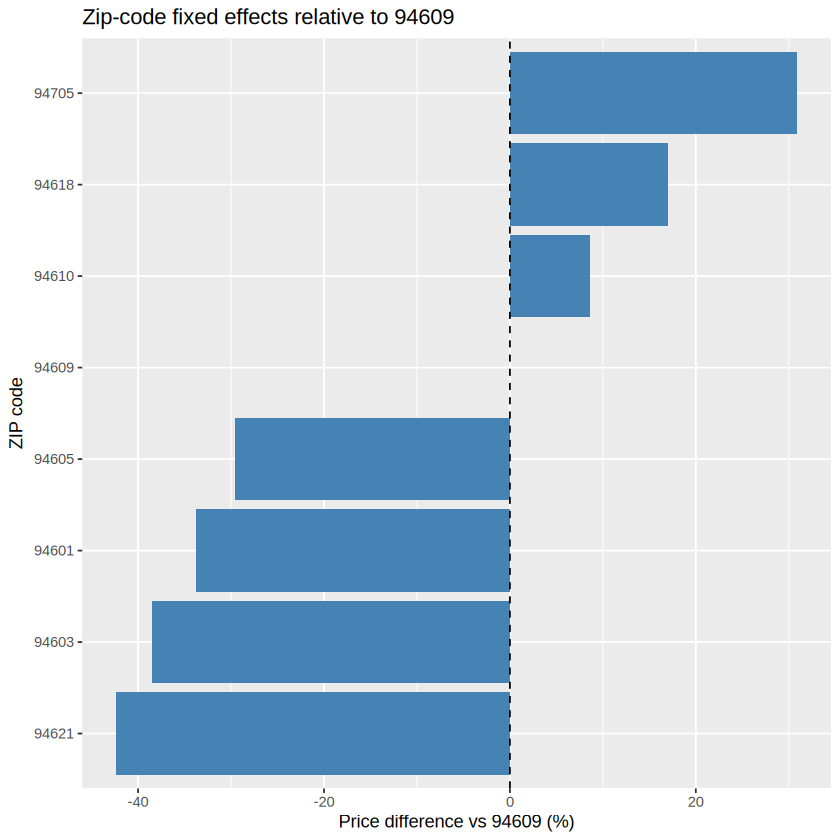

In [105]:
library(ggplot2)

zips_focus <- c("94601", "94603", "94605", "94621",
                "94609",  # baseline (we'll add as 0)
                "94610", "94618", "94705")

zip_plot_df <- zip_effects %>%
  filter(zip_code %in% zips_focus) %>%
  # add baseline row explicitly
  bind_rows(tibble(
    zip_code = "94609",
    estimate = 0,
    pct_diff = 0,
    std.error = NA_real_,
    p.value  = NA_real_
  )) %>%
  distinct(zip_code, .keep_all = TRUE)

# now sort by pct_diff and set factor order
zip_plot_df <- zip_plot_df %>%
  arrange(pct_diff) %>%
  mutate(zip_code = factor(zip_code, levels = zip_code))

ggplot(zip_plot_df, aes(x = zip_code, y = pct_diff)) +
  geom_col(fill = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    x = "ZIP code",
    y = "Price difference vs 94609 (%)",
    title = "Zip-code fixed effects relative to 94609"
  ) +
  coord_flip()


In [106]:
zip_plot_df <- zip_plot_df %>%
  arrange(pct_diff) %>%
  mutate(zip_code = factor(zip_code, levels = zip_code))


In [107]:
library(dplyr)

homes_df_plot_zip <- homes_df %>%
  mutate(
    log_price_hat_zip = predict(model_ols_zip, newdata = homes_df),
    price_hat_zip     = exp(log_price_hat_zip)
  )


Warning message:
“Removed 361 rows containing missing values or values outside the scale range
(`geom_point()`).”


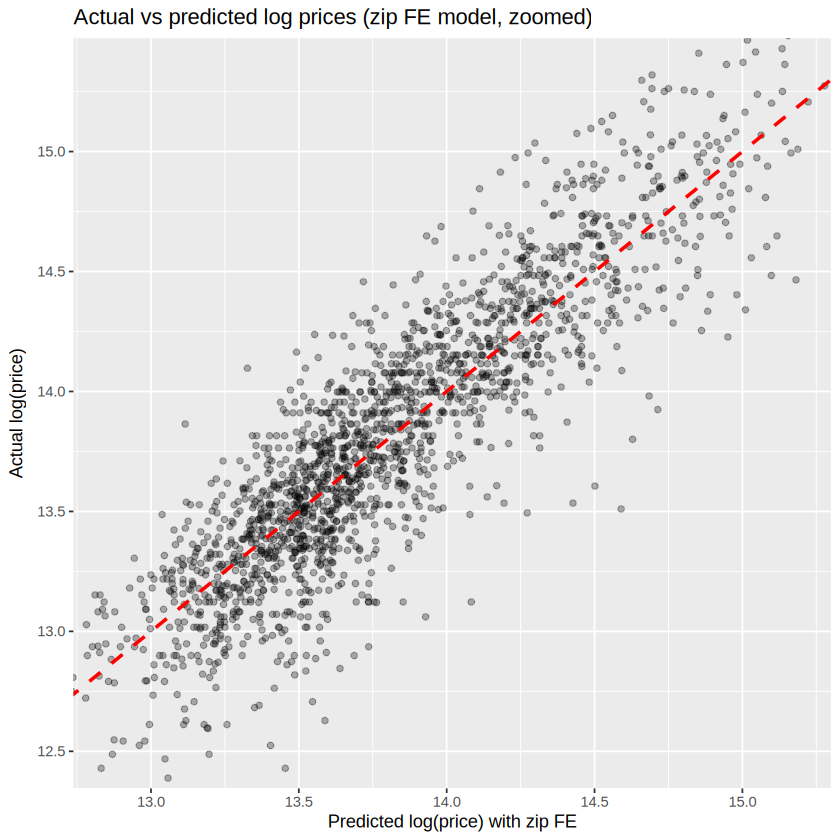

In [108]:
library(ggplot2)

# central quantiles for zooming
x_q_zip <- quantile(homes_df_plot_zip$log_price_hat_zip,
                    probs = c(0.01, 0.99), na.rm = TRUE)
y_q_zip <- quantile(log(homes_df_plot_zip$PRICE),
                    probs = c(0.01, 0.99), na.rm = TRUE)

ggplot(homes_df_plot_zip,
       aes(x = log_price_hat_zip, y = log(PRICE))) +
  geom_point(alpha = 0.3) +
  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = "dashed",
    color = "red",
    linewidth = 1
  ) +
  coord_cartesian(xlim = x_q_zip, ylim = y_q_zip) +
  labs(
    x = "Predicted log(price) with zip FE",
    y = "Actual log(price)",
    title = "Actual vs predicted log prices (zip FE model, zoomed)"
  )


In [109]:
library(dplyr)
library(forcats)

homes_df <- homes_df %>%
  mutate(
    property_type = as.factor(`PROPERTY TYPE`),
    property_type = fct_relevel(property_type, "Single Family Residential")
  )


In [110]:
model_ols_zip_pt <- lm(
  log(PRICE) ~ BATHS + BEDS + `SQUARE FEET`+
    is_HOLC_A + is_HOLC_B + is_HOLC_D +
    within_0_5_mile_quality_school +
    dist_to_employer_miles + dist_to_shopping_center_miles +
    sale_year + zip_code + property_type,   # ← new term
  data = homes_df
)

summary(model_ols_zip_pt)



Call:
lm(formula = log(PRICE) ~ BATHS + BEDS + `SQUARE FEET` + is_HOLC_A + 
    is_HOLC_B + is_HOLC_D + within_0_5_mile_quality_school + 
    dist_to_employer_miles + dist_to_shopping_center_miles + 
    sale_year + zip_code + property_type, data = homes_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.7216 -0.1392  0.0206  0.1587  0.7509 

Coefficients:
                                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)                           1.320e+01  5.313e-02 248.457  < 2e-16 ***
BATHS                                 7.269e-02  1.318e-02   5.516 3.96e-08 ***
BEDS                                  2.265e-02  9.373e-03   2.416 0.015783 *  
`SQUARE FEET`                         2.471e-04  1.496e-05  16.518  < 2e-16 ***
is_HOLC_A                             3.481e-03  3.046e-02   0.114 0.909024    
is_HOLC_B                             2.622e-02  2.180e-02   1.202 0.229329    
is_HOLC_D                            -7.137e-02  2.628e-02  -2.715 0.00

In [111]:
library(dplyr)
library(tidyr)

model_df <- homes_df %>%
  select(
    PRICE,
    BATHS, BEDS, `SQUARE FEET`,
    is_HOLC_A, is_HOLC_B, is_HOLC_D,
    within_0_5_mile_quality_school,
    dist_to_employer_miles, dist_to_shopping_center_miles,
    sale_year, zip_code, property_type
  ) %>%
  drop_na() %>%
  mutate(
    log_price = log(PRICE),
    sale_year = factor(sale_year),
    zip_code = factor(zip_code),
    property_type = factor(property_type)
  )


In [112]:
library(glmnet)

x <- model.matrix(
  log_price ~
    BATHS + BEDS + `SQUARE FEET` +
    is_HOLC_A + is_HOLC_B + is_HOLC_D +
    within_0_5_mile_quality_school +
    dist_to_employer_miles + dist_to_shopping_center_miles +
    sale_year + zip_code + property_type,
  data = model_df
)

# drop intercept column
x <- x[, -1]

y <- model_df$log_price


In [113]:
set.seed(123)

lasso_cv <- cv.glmnet(
  x, y,
  alpha = 1,       # LASSO
  nfolds = 10
)

lasso_cv$lambda.min   # lambda that minimizes CV error
lasso_cv$lambda.1se   # 1-SE rule (sparser model)


[1] 0.0008410384

[1] 0.03814007

In [114]:
library(tibble)
library(dplyr)

coef_1se <- coef(lasso_cv, s = "lambda.1se")

coef_tbl_1se <- coef_1se %>%
  as.matrix() %>%
  as.data.frame() %>%
  rownames_to_column("variable") %>%
  rename(coefficient = 2) %>%
  as_tibble()

# kept (non-zero)
vars_kept_1se <- coef_tbl_1se %>%
  filter(variable != "(Intercept)", coefficient != 0)

# shrunk to zero
vars_removed_1se <- coef_tbl_1se %>%
  filter(variable != "(Intercept)", coefficient == 0)

vars_kept_1se
vars_removed_1se


variable,coefficient
<chr>,<dbl>
BATHS,0.0297794575
BEDS,0.0093216049
`SQUARE FEET`,0.0003324844
is_HOLC_A,0.0794839828
is_HOLC_B,0.0587959839
is_HOLC_D,-0.0432277254
within_0_5_mile_quality_school,0.0114333021
dist_to_shopping_center_miles,-0.0058504351
zip_code94601,-0.1068613562


variable,coefficient
<chr>,<dbl>
dist_to_employer_miles,0
sale_year2021,0
sale_year2022,0
sale_year2023,0
sale_year2024,0
sale_year2025,0
zip_code94501,0
zip_code94560,0
zip_code94577,0


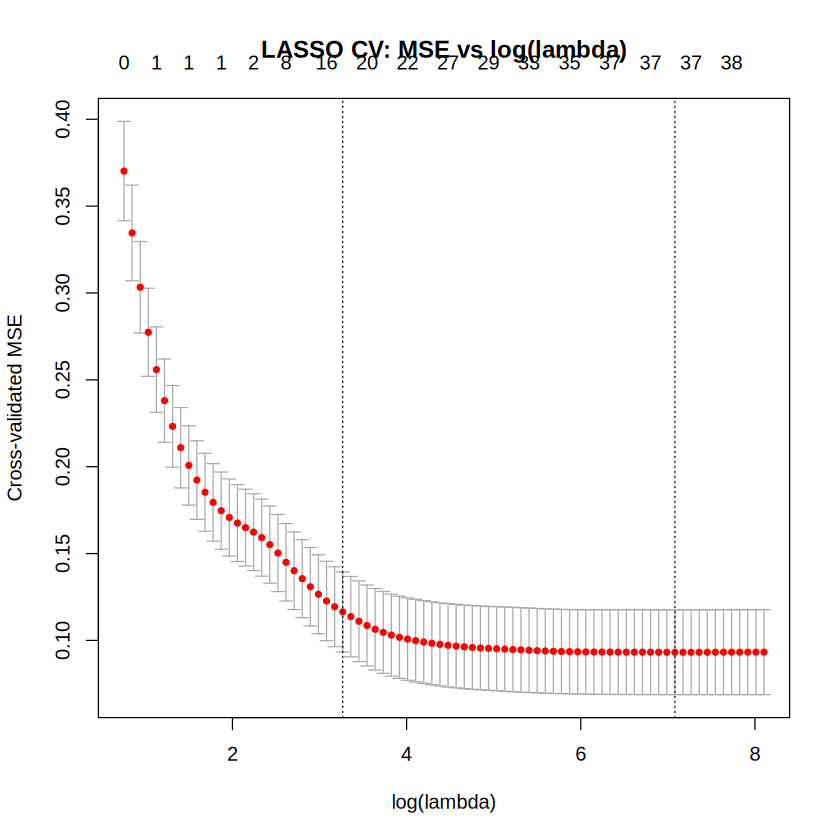

In [115]:
plot(lasso_cv,
     xlab = "log(lambda)",
     ylab = "Cross-validated MSE",
     main = "LASSO CV: MSE vs log(lambda)")


In [116]:
# Non-zero coefficients at lambda.min
coef_min <- coef(lasso_cv, s = "lambda.min")
nz_min   <- sum(coef_min != 0) - 1   # minus 1 to drop intercept

# Non-zero coefficients at lambda.1se
coef_1se <- coef(lasso_cv, s = "lambda.1se")
nz_1se   <- sum(coef_1se != 0) - 1

nz_min
nz_1se


[1] 37

[1] 18

In [118]:
library(broom)
library(dplyr)
library(stringr)

zip_effects <- tidy(model_ols_zip_pt) %>%
  filter(str_starts(term, "zip_code")) %>%      # keep only zip dummies
  mutate(
    zip_code = str_remove(term, "^zip_code"),   # "zip_code94601" -> "94601"
    pct_diff_vs_94609 = (exp(estimate) - 1) * 100
  ) %>%
  select(zip_code, estimate, pct_diff_vs_94609, std.error, p.value)


In [119]:
zip_D_share <- homes_df %>%
  group_by(zip_code) %>%
  summarise(
    n_listings   = n(),
    share_HOLC_D = mean(is_HOLC_D, na.rm = TRUE)
  )


In [120]:
zip_summary <- zip_effects %>%
  mutate(zip_code = factor(zip_code)) %>%
  full_join(zip_D_share, by = "zip_code") %>%
  # add baseline 94609 row (0% vs itself)
  bind_rows(tibble(
    zip_code = factor("94609"),
    estimate = 0,
    pct_diff_vs_94609 = 0,
    std.error = NA_real_,
    p.value  = NA_real_,
    n_listings = sum(homes_df$zip_code == "94609", na.rm = TRUE),
    share_HOLC_D = mean(homes_df$is_HOLC_D[homes_df$zip_code == "94609"], na.rm = TRUE)
  )) %>%
  distinct(zip_code, .keep_all = TRUE) %>%
  arrange(pct_diff_vs_94609)

zip_summary


zip_code,estimate,pct_diff_vs_94609,std.error,p.value,n_listings,share_HOLC_D
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
94704,-0.55585039,-42.641572,0.30498940,6.853807e-02,1,0.000000000
94621,-0.50604274,-39.712340,0.06744086,9.626109e-14,88,0.625000000
94603,-0.44319740,-35.801953,0.05109062,8.954387e-18,145,0.303448276
94601,-0.40654386,-33.405211,0.05271316,2.010089e-14,128,0.210937500
94606,-0.30940138,-26.611386,0.05435660,1.457993e-08,64,0.187500000
94605,-0.26028471,-22.916791,0.05584062,3.369917e-06,337,0.068249258
94577,-0.22820329,-20.403757,0.07938141,4.089765e-03,21,0.000000000
94619,-0.15653758,-14.490061,0.05746952,6.513955e-03,170,0.000000000
94560,-0.14060766,-13.116988,0.30589017,6.458096e-01,1,0.000000000


In [121]:
install.packages("ggrepel")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text_repel()`).”


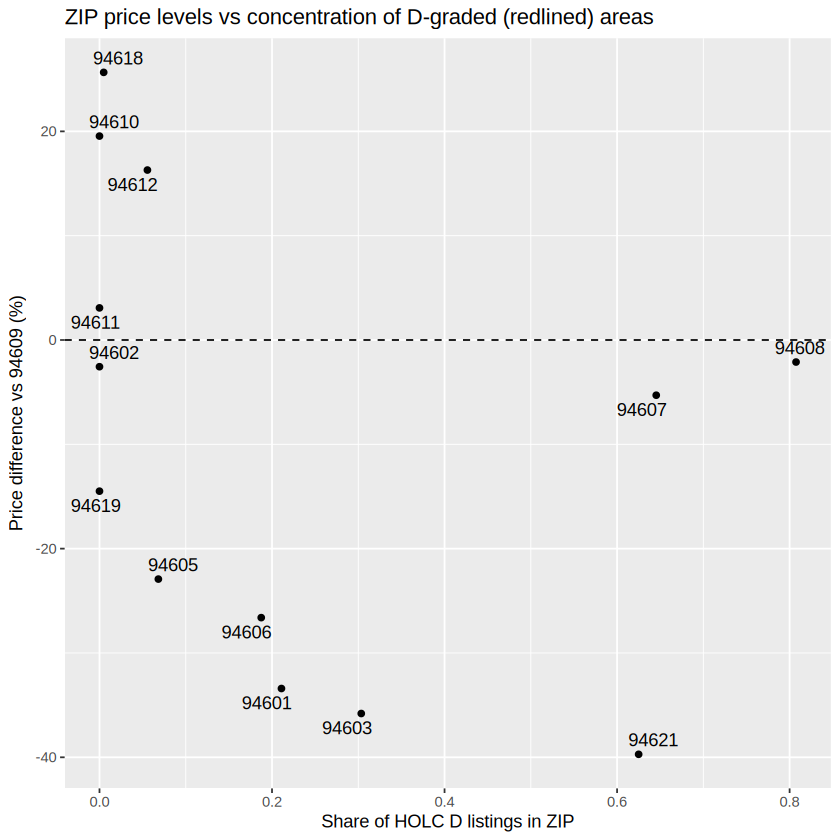

In [122]:
library(ggplot2)
library(dplyr)

# Optional: focus on Oakland-ish zips
oak_zips <- c("94601","94602","94603","94605","94606","94607",
              "94608","94609","94610","94611","94612","94618",
              "94619","94621")

zip_plot <- zip_summary %>%
  filter(as.character(zip_code) %in% oak_zips)

ggplot(zip_plot, aes(x = share_HOLC_D, y = pct_diff_vs_94609, label = zip_code)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_point() +
  ggrepel::geom_text_repel() +  # if you have ggrepel installed; otherwise remove this line
  labs(
    x = "Share of HOLC D listings in ZIP",
    y = "Price difference vs 94609 (%)",
    title = "ZIP price levels vs concentration of D-graded (redlined) areas"
  )

# Takeaway Look for D-level / historically redlined areas that ALSO have a Pixar-level employer, waterfront/downtown proximity, and active infill development — places where the “big forces” are strong enough to bend the usual D discount at the zip level

94607 and 94608 both have a pretty high share of HOLC D,

but their price difference vs 94609 is basically ~0% (or even slightly positive for 94608),

whereas other high-D zips (94601, 94603, 94621) are −30–45% cheaper.

So the story is roughly:

94607 = West Oakland / Jack London

Lots of historically D-graded areas.

But also super strong location advantages: right next to downtown, BART, the waterfront, new lofts/condos, SF access, etc.

Those forces have pushed prices up enough to offset the D penalty at the zip level.

94608 = North Oakland / Emeryville

Historically redlined pockets, but: Pixar, Bay Street, tons of new development, very SF-adjacent.

Again, big gentrification + job center + retail story that counteracts the “redlined zip = cheap” pattern.

In [89]:
library(dplyr)

amenities_sf <- amenities_sf %>%
  mutate(
    employer_type = dplyr::case_when(
      category != "employer" ~ NA_character_,
      name %in% c(
        "Pixar Animation Studios",
        "Kaiser Permanente HQ - Oakland"
      ) ~ "clean_office",
      name %in% c(
        "Port of Oakland - Seaport",
        "Oakland Int'l Airport & Cargo (OAK)",
        "Oakland Global Trade & Logistics Hub",
        "Amtrak Oakland Maintenance Facility",
        "Tesla Fremont Factory"
      ) ~ "heavy_industrial",
      TRUE ~ NA_character_
    )
  )


In [90]:
library(sf)
library(tibble)
library(purrr)

# helper: min distance in miles from each home to amenities of a given employer_type
dist_to_employer_type <- function(type_name, col_name) {
  pts <- amenities_sf %>%
    filter(employer_type == type_name)

  # if no points of that type, return NA column
  if (nrow(pts) == 0) {
    return(tibble(!!col_name := NA_real_))
  }

  dmat <- st_distance(homes_sf, pts)  # meters
  min_meters <- apply(dmat, 1, min)
  min_miles  <- as.numeric(min_meters) / 1609.34

  tibble(!!col_name := min_miles)
}

dist_clean_office  <- dist_to_employer_type("clean_office",  "dist_to_clean_office_miles")
dist_heavy_industr <- dist_to_employer_type("heavy_industrial", "dist_to_heavy_industrial_miles")


In [91]:
homes_df <- homes_df %>%
  bind_cols(dist_clean_office, dist_heavy_industr)


In [92]:
model_ols_split_emp <- lm(
  log(PRICE) ~ BATHS + BEDS +
    is_HOLC_A + is_HOLC_B + is_HOLC_D +
    within_0_5_mile_quality_school +
    dist_to_clean_office_miles +
    dist_to_heavy_industrial_miles +
    dist_to_shopping_center_miles +
    sale_year + zip_code + property_type,
  data = homes_df
)

summary(model_ols_split_emp)



Call:
lm(formula = log(PRICE) ~ BATHS + BEDS + is_HOLC_A + is_HOLC_B + 
    is_HOLC_D + within_0_5_mile_quality_school + dist_to_clean_office_miles + 
    dist_to_heavy_industrial_miles + dist_to_shopping_center_miles + 
    sale_year + zip_code + property_type, data = homes_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.7406 -0.1542  0.0133  0.1709  0.8864 

Coefficients:
                                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)                          12.907978   0.065115 198.235  < 2e-16 ***
BATHS                                 0.191267   0.011690  16.361  < 2e-16 ***
BEDS                                  0.075113   0.009405   7.986 2.43e-15 ***
is_HOLC_A                             0.064666   0.032631   1.982 0.047656 *  
is_HOLC_B                             0.036354   0.023193   1.567 0.117176    
is_HOLC_D                            -0.079591   0.028181  -2.824 0.004790 ** 
within_0_5_mile_quality_school        0.084388   0.017755